# Does the Payout–Leverage Relationship Vary with the Interest Rate Regime?
### Industry-Level Evidence from US Non-Financial Firms, 1999–2025 — *analysis pipeline*

Milan Kalajdžić · University of Warsaw, Faculty of Economic Sciences · *Quantitative Finance MA*
Supervisor: dr hab. Piotr Boguszewski

---

Empirical pipeline for Chapters **4 (Data)**, **5 (Methodology)** and **6 (Results)**. It builds an
**industry × year panel** from the Damodaran datasets (1999–2025), merges macro series from **FRED**, and
estimates fixed-effects panel regressions of payout on leverage with a **leverage × rate-regime interaction**
(the central test of **H2**), plus the **H3** tangibility moderation.

> **Full 27-year panel.** Years are auto-detected from each file's internal date stamp (newer files) or its
> filename (older archives). The loader is **era-proof**: it handles Damodaran's three structural layouts
> (the 1999–2012 `Sheet1` files, the 2013–2017 transition, and the 2018+ `Industry Averages` files) and
> selects columns by keyword so year-to-year renames don't break it.

> **Two things the long panel changes vs an 8-year run:**
> 1. **Regime definition.** With 1999–2025 spanning several tightening cycles (early-2000s, mid-2000s,
>    2022+), the **rate-level threshold** is the primary regime variable (not the post-2022 binary, which
>    would lump 23 disparate years together). Both are reported.
> 2. **Industry reconciliation.** Damodaran reorganised his classification at **2012→2013**. A conservative
>    rename map fixes unambiguous variants; a **stable-core sample** (industries present ≥ N years) provides
>    a robustness check immune to the reclassification. See §2 and Appendix B.

> 3. **Data-quality fixes (Sept 2026).** Damodaran's 2013–2015 capex files report depreciation on a
>    different basis (industry depreciation roughly halves while capex does not), which inflates
>    Cap Ex/Depreciation and scrambles the industry ranking. Depreciation-based tangibility is set to missing
>    in those years (per-year check in §2). The H3 model now includes the tangibility main effect, and the
>    H3 proxy-robustness loop applies the same industry reconciliation as the main panel.

> 4. **`dbtfund` (Sept 2026).** Tangibility for H3 is now **PP&E / total assets**, the standard measure, used as a
>    within-year percentile rank because its definition changes in 2013 and 2017; the capex proxies become
>    robustness checks. Book leverage, market leverage without leases and **Debt/EBITDA** (debt relative to
>    cash flow, the closest available measure of debt-service burden) re-test H1/H2 in §9d.

> **Code layout.** The reusable machinery (file readers, sample checks, estimators, multiple-testing tools)
> lives in the `paylev` package in `src/`, where it is covered by the tests in `tests/`. This notebook makes
> the research choices and runs the analysis from top to bottom.

| Section | Thesis |
|---|---|
| 0 Setup · 1 Load · 2 Filters & reconciliation | §5.6, §4.1–4.2, App. B |
| 3 FRED & regime · 4 Variables | §4.1, §4.3 |
| 5 Descriptives · 6 Baseline · 7 Interaction (H1/H2) · 8 Tangibility (H3) · 8b Dividend smoothing | §4.4, §5–6 |
| 9 Robustness · 10 Tables & verdicts · 11 Figures · 12 Reproducibility | §5.5, §6, App. A/C/D |

## 0 · Setup & configuration  <span style="color:gray">(§5.6)</span>

In [1]:
# Install once:  pip install -e ".[dev]"   (see the README)

import os, warnings, sys, platform, re
from functools import partial
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 70)
try:
    import paylev
except ImportError:                 # package not installed: use the copy in src/
    sys.path.insert(0, str(Path("src").resolve())); import paylev
try:
    from linearmodels.panel import PanelOLS
    HAVE_LM = True
except Exception:
    HAVE_LM = False; print("linearmodels missing -> %pip install linearmodels")
from paylev.plotting import THEMES, use as use_theme, save as save_fig, dot, runs, shade, diverging, ink_on, minus
T = use_theme(THEMES["print"], base_size=9)   # figures: white page, drawn at A4 text width (6.5 in), 9 pt text
FIG_DPI = 300
print("Python", sys.version.split()[0], "| pandas", pd.__version__, "| paylev", paylev.__version__)

Python 3.11.15 | pandas 3.0.2 | paylev 1.0.0


In [2]:
# ============================ CONFIGURATION ============================
# Damodaran files: searched recursively, absent paths ignored. PAYLEV_DATA overrides it (the tests use fake data).
SEARCH_DIRS = os.environ["PAYLEV_DATA"].split(os.pathsep) if "PAYLEV_DATA" in os.environ else ["data", "."]

# Tangibility for H3 (see §4).
#   "ppe_assets"     -> PP&E / total assets from dbtfund  (PRIMARY: the standard measure, e.g. Rajan & Zingales 1995)
#                       Its definition changes twice (PPE_DEF_CHANGES): Fixed Assets/BV of Capital (1999-2012),
#                       Fixed Assets/Total Assets (2013-2016), Net PP&E/Total Assets (2017+). It is therefore used
#                       as a percentile rank within each year, which is comparable across the definitions.
#   "capex_deprec"   -> Cap Ex / Depreciation            (robustness)
#   "netcapex_sales" -> Net Cap Ex / Sales                (robustness)
#   "invcap_sales"   -> 1 / (Sales / Invested Capital)   (robustness)
TANGIBILITY_PROXY = "ppe_assets"
from paylev.damodaran import CAPEX_PROXIES, DEPREC_PROXIES   # which proxies come from capex / use depreciation
PPE_DEF_CHANGES   = [2013, 2017]
# Damodaran's 2013-2015 capex files report depreciation on a different basis (industry depreciation drops
# by roughly half vs 2012/2016 while capex does not), inflating Cap Ex/Depreciation and scrambling the
# industry ranking. Proxies built from depreciation are set to missing in these years (see the §2 check).
TANG_BREAK_YEARS = [2013, 2014, 2015]

# Rate regime (§4.3.3). With the long panel the threshold captures multiple cycles.
HIGH_RATE_RULE = "threshold"   # "threshold" (primary) or "post2022"
FFR_THRESHOLD  = 3.0           # annual-avg fed funds % defining "high"
HIKE_THRESHOLD = 0.25          # rise in annual-avg fed funds (pp) that counts as a hiking year (§8b)
RECLASS_YEAR   = 2013          # Damodaran's industry reclassification: year-on-year changes across it are
                               # composition shifts, so change/lag models in §8b drop this year

# Equivalence test for H2 (§9b): largest regime effect still considered economically negligible,
# in payout-ratio units per 1 SD of leverage (0.05 is about 14% of the mean payout of 0.35).
EQUIV_MARGIN = 0.05

# FRED macro data:
#   "snapshot" -> pinned monthly/quarterly vintage in data/fred/fred_snapshot.csv (exactly reproducible)
#   "live"     -> download the current vintage with pandas-datareader (GDP is revised over time)
FRED_SOURCE   = "snapshot"
FRED_SNAPSHOT = Path("data/fred/fred_snapshot.csv")

# Sample construction
WINSOR_P         = 0.01
# Ratios are undefined when their denominator is not positive (payout = D/earnings, D/FCFE, total payout/NI).
# Damodaran still reports values there (e.g. payout ~0.003 for loss-making industries that pay dividends),
# so they are set to missing. The as-reported payout is kept as a robustness check (§9).
POSITIVE_DENOMINATORS = True
CROSSFILE_MIN_AGREE = 0.75     # min share of industries whose divfund payout matches divfcfe D/NI (±5%)
# Row alignment (§2): an industry has the same number of firms in every file of a year. In a file-year where
# most counts match divfund, a row whose count differs belongs to another industry (e.g. wacc99, where a block
# of rows is shifted by one) and that file's variables are set to missing for it. Where most counts differ,
# the file is a different vintage of the universe and is left as it is (reported in the alignment table).
ALIGN_MIN_SHARE = 0.5
EXCLUDE_FIN_UTIL = True
MIN_YEARS_CORE   = 20          # stable-core robustness: keep industries present >= this many years
COVID_YEARS      = [2020, 2021]
GFC_YEARS        = [2008, 2009]   # financial crisis, dropped in a robustness check (§9)
DK_BANDWIDTH     = 3           # lags for Driscoll-Kraay standard errors (about T^(1/3) with 27 years, §9)
RW_BOOT          = int(os.environ.get("PAYLEV_RW_BOOT", 999))   # cluster-bootstrap draws, Romano-Wolf (§10b)
RW_SEED          = 2026

OUTDIR = Path(os.environ.get("PAYLEV_OUTDIR", "outputs")); OUTDIR.mkdir(parents=True, exist_ok=True)
print("Config OK | regime:", HIGH_RATE_RULE, "| tangibility:", TANGIBILITY_PROXY,
      "| core>=", MIN_YEARS_CORE, "yrs | FRED:", FRED_SOURCE)

Config OK | regime: threshold | tangibility: ppe_assets | core>= 20 yrs | FRED: snapshot


## 1 · Load the Damodaran datasets  <span style="color:gray">(§4.1–4.2)</span>

`divfund` (payout, ROE, market cap) · `divfcfe` (dividends, FCFE) · `wacc` (leverage D/(D+E), tax) ·
`capex` (capex-based tangibility proxies) ·
`dbtfund` (PP&E / assets, book and lease-unadjusted leverage, EBITDA / EV). The readers (`paylev.damodaran`) are **era-proof**: they locate the industry sheet and header
row wherever they sit, derive the data year from the internal stamp or filename, and match columns by
keyword. *Verified against every file from 1999 to 2025.*

In [3]:
from paylev.damodaran import (TOKENS, read_industry_sheet, pick, pick_fcfe, pick_div, data_year,
                              discover_sources, load_year)
# One year of rows merged across the five files (see paylev/damodaran.py), with this notebook's choices:
load_year = partial(load_year, tangibility_proxy=TANGIBILITY_PROXY, positive_denominators=POSITIVE_DENOMINATORS)

In [4]:
SOURCES = {t: discover_sources(t, SEARCH_DIRS) for t in TOKENS}
all_years = sorted(set().union(*[set(v) for v in SOURCES.values()]))
grid = pd.DataFrame({t: ["Y" if y in SOURCES[t] else "." for y in all_years] for t in SOURCES},
                    index=all_years)
grid.index.name = "year"
print(f"Coverage ({len(all_years)} years {min(all_years)}-{max(all_years)}):")
print(grid.T.to_string())

years = sorted(set(SOURCES["divfund"]) & set(SOURCES["wacc"]))
raw = pd.concat([load_year(y, SOURCES) for y in years], ignore_index=True)
print(f"\nRaw panel: {len(years)} years | {raw['industry'].nunique()} distinct names | {len(raw)} rows")
raw.head()

Coverage (27 years 1999-2025):
year    1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025
divfund    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
divfcfe    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
wacc       Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
capex      Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
dbtfund    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y



Raw panel: 27 years | 219 distinct names | 2652 rows


,industry,year,payout,roe,n_firms,mktcap,lev,tax,nf_wacc,nf_divfcfe,div_usd,ni_usd,div_to_fcfe,div_yield,nf_capex,capex_deprec,nf_dbtfund,lev_unadj,lev_book,lev_dbt,ebitda_ev,ppe_assets,capex_assets,debt_ebitda_rep,int_cov,tangibility,totpayout_ni
0,Advertising,1999,0.246424,0.134948,28,58326.4895,0.098560,0.447821,28.0,28.0,266.0,1079.0,0.214171,0.004561,28.0,0.852036,28.0,0.098560,0.469885,0.098560,0.070291,0.155017,0.061801,NaN,NaN,0.155017,NaN
1,Aerospace/Defense,1999,0.245589,0.133937,48,111866.7804,0.267524,0.348131,48.0,48.0,1455.0,5926.0,0.254460,0.013007,48.0,0.902343,48.0,0.267524,0.479951,0.267524,0.138195,0.162030,0.052059,NaN,NaN,0.162030,NaN
2,Air Transport,1999,0.052681,0.189568,42,84075.3787,0.346738,0.372312,42.0,42.0,385.0,7314.0,0.434537,0.004579,42.0,2.203980,42.0,0.346738,0.553515,0.346738,0.223271,0.591270,0.209627,NaN,NaN,0.591270,NaN
3,Alternate Energy,1999,0.118465,0.139224,5,13400.0999,NaN,NaN,NaN,5.0,55.0,461.0,0.364238,0.004104,5.0,1.849453,5.0,0.483904,0.820724,0.483904,0.097176,0.472635,0.062729,NaN,NaN,0.472635,NaN
4,Aluminum,1999,0.166057,0.092600,9,35307.2390,0.483904,0.288303,5.0,9.0,259.0,1562.0,0.447323,0.007336,9.0,1.279888,9.0,0.220551,0.410099,0.220551,0.158002,0.196418,0.097814,NaN,NaN,0.196418,NaN


## 2 · Sample construction, filters & industry reconciliation  <span style="color:gray">(§4.2, App. B)</span>

- Drop aggregate rows; exclude **financials & regulated utilities** (era-aware keyword list).
- **Reconcile industry names** across the 2012→2013 reclassification via a *conservative* map — only
  unambiguous spelling/punctuation variants and clear 1:1 relabels (extend `INDUSTRY_RENAME` as needed).
- Set depreciation-based tangibility to missing in the 2013–2015 break years (see the data check below).
- Winsorise ratio variables; report industry **persistence** (Appendix B) and define the **stable core**.

In [5]:
AGG_ROWS = ["Total Market", "Total Market (without financials)", "Grand Total",
            "Market", "Other", "Unclassified"]
# era-aware financial / regulated-utility exclusions (lower-cased substring match)
FIN_UTIL_KEYS = ["bank", "insurance", "financ", "investment", "utilit", "power", "r.e.i.t", "reit",
                 "reinsurance", "brokerage", "trust", "thrift", "securities", "electric util",
                 "natural gas (distrib", "natural gas util", "water utility", "telecom. utility",
                 "public/private equity", "real estate"]

# Conservative reconciliation: unambiguous variants + clear 1:1 relabels only.
INDUSTRY_RENAME = {
    # --- spelling / punctuation / typo variants ---
    "Furn./Home Furnishings": "Furn/Home Furnishings",
    "Paper & Forest Products": "Paper/Forest Products",
    "Office Equip & Supplies": "Office Equip/Supplies",
    "Oilfield Services/Equip.": "Oilfield Svcs/Equip.",
    "Semiconductor Cap Eq": "Semiconductor Equip",
    "Semiconductor Cap Equip": "Semiconductor Equip",
    "Manuf. Housing/Rec Veh": "Manuf. Housing/RV",
    "Computer Software & Svcs": "Computer Software/Svcs",
    "Heavy Truck/Equip Makers": "Heavy Truck & Equip",
    "Natural Gas (Diversified": "Natural Gas (Div.)",
    "Natural Gas (Diversified)": "Natural Gas (Div.)",
    "Publshing & Newspapers": "Publishing & Newspapers",
    "Retail Automotive": "Retail (Automotive)",
    "Retail Building Supply": "Retail (Building Supply)",
    "Auto Parts (OEM)": "Auto Parts",
    "Auto Parts (Replacement)": "Auto Parts",
    "Trucking/Transp. Leasing": "Trucking",
    "Gold/Silver Mining": "Precious Metals",
    # --- clear 1:1 relabels across the 2013 reclassification ---
    "Beverage (Soft Drink)": "Beverage (Soft)",
    "Educational Services": "Education",
    "Railroad": "Transportation (Railroads)",
    "Restaurant": "Restaurant/Dining",
    "Tire & Rubber": "Rubber& Tires",
    "Metals & Mining (Div.)": "Metals & Mining",
    "Environmental": "Environmental & Waste Services",
    "Newspaper": "Publishing & Newspapers",
    "Publishing": "Publishing & Newspapers",
}

from paylev.sample import (is_fin_util, clean_sample, winsorize, check_row_alignment, check_value_agreement,
                           crossfile_agreement)
winsorize = partial(winsorize, p=WINSOR_P)

# Row alignment: compare each file's firm count with divfund's for the same industry and year (raw names,
# before reconciliation). Variables from a misaligned row are set to missing; see ALIGN_MIN_SHARE.
_TANG_SRC = "dbtfund" if TANGIBILITY_PROXY == "ppe_assets" else "capex"
ALIGN_VARS = {"wacc": ["lev", "tax"],
              "divfcfe": ["div_usd", "ni_usd", "div_to_fcfe", "totpayout_ni", "div_yield"],
              "capex": ["capex_deprec"] + (["tangibility"] if _TANG_SRC == "capex" else []),
              "dbtfund": ["lev_unadj", "lev_dbt", "lev_book", "ebitda_ev", "ppe_assets", "capex_assets", "debt_ebitda_rep",
                          "int_cov"]
                         + (["tangibility"] if _TANG_SRC == "dbtfund" else [])}
raw, _counts = check_row_alignment(raw, ALIGN_VARS, ALIGN_MIN_SHARE, AGG_ROWS)
# Second check: wacc's D/(D+E) is the same number as dbtfund's market debt ratio on the same definition. A shifted
# row whose neighbour has the same firm count passes the count check but not this one.
raw, _values = check_value_agreement(raw, {"wacc": ("lev", "lev_dbt", ["lev", "tax"])}, agg_rows=AGG_ROWS)
alignment_check = pd.concat(
    [_counts.rename(columns={"share_same_count": "share_agree"}).assign(check="firm count vs divfund"),
     _values.rename(columns={"share_same_value": "share_agree"}).assign(check="D/(D+E) vs dbtfund")],
    ignore_index=True)[["check", "file", "year", "share_agree", "rows_set_missing", "treated_as"]]
for chk, g_ in alignment_check.groupby("check", sort=False):
    fix_ = g_[g_["rows_set_missing"] > 0]
    kept_ = g_[~g_["treated_as"].isin(["aligned", "same values"])]
    print(f"Row alignment ({chk}): rows set to missing ->",
          ", ".join(f"{r.file}{r.year % 100:02d}: {r.rows_set_missing}" for r in fix_.itertuples()) or "none")
    if len(kept_):
        print("  differ throughout (other vintage or computation, kept):",
              ", ".join(f"{r.file}{r.year % 100:02d}" for r in kept_.itertuples()))

# Debt / EBITDA = D/(D+E) / (EBITDA/EV): debt relative to cash flow, not to equity value, so it does not move
# with stock prices. Undefined when EBITDA <= 0. It uses the main (wacc) leverage, i.e. the same debt definition.
raw["debt_ebitda"] = raw["lev"] / raw["ebitda_ev"].where(raw["ebitda_ev"] > 0)
# Book D/(D+E) is only meaningful with positive book equity: values >= 1 (negative equity, e.g. restaurants and
# tobacco after years of buybacks) or < 0 are undefined, like the other ratios with a non-positive denominator.
if POSITIVE_DENOMINATORS:
    raw.loc[~raw["lev_book"].between(0, 1, inclusive="left"), "lev_book"] = np.nan
# Validation: Damodaran reports Debt/EBITDA himself in 2018 and 2022+ (slightly different debt and EV
# definitions), so the constructed measure should rank industries the same way in those years.
_nm = raw["industry"].replace(INDUSTRY_RENAME)
_r = raw[~_nm.isin(AGG_ROWS) & ~_nm.apply(lambda n: is_fin_util(n, FIN_UTIL_KEYS)) & raw["debt_ebitda"].notna() & (raw["debt_ebitda_rep"] > 0)]
debt_ebitda_check = pd.DataFrame([{"year": int(y), "n": len(g_),
                                   "rank_corr": round(g_["debt_ebitda"].corr(g_["debt_ebitda_rep"], method="spearman"), 3),
                                   "median_ratio_constructed_to_reported": round((g_["debt_ebitda"] / g_["debt_ebitda_rep"]).median(), 3)}
                                  for y, g_ in _r.groupby("year")])
raw = raw.drop(columns=["ebitda_ev", "debt_ebitda_rep", "int_cov", "lev_dbt"])

panel = clean_sample(raw, INDUSTRY_RENAME, AGG_ROWS, FIN_UTIL_KEYS if EXCLUDE_FIN_UTIL else None)
panel_prewin = panel.copy()      # kept for the per-year data-quality check below

# Cross-file consistency: divfund's payout ratio vs dividends / net income from divfcfe (same year, same
# industry). A year in which most industries disagree points to a scrambled divfcfe file (e.g. 2007, where
# the net-income column does not match the industries); measures built from divfcfe are set to missing there.
crossfile_agreement = crossfile_agreement(raw, INDUSTRY_RENAME, panel["industry"])
DIVFCFE_BAD_YEARS = sorted(int(y) for y in crossfile_agreement[crossfile_agreement < CROSSFILE_MIN_AGREE].index)
print(f"divfcfe vs divfund agreement below {CROSSFILE_MIN_AGREE:.0%} in {DIVFCFE_BAD_YEARS}: "
      f"divfcfe-based measures set to missing in those years")
panel.loc[panel["year"].isin(DIVFCFE_BAD_YEARS), ["div_to_fcfe", "totpayout_ni"]] = np.nan
panel = panel.drop(columns=["div_usd", "ni_usd"])   # dollar levels stay in `raw` (summed where needed, §8b)

# Payout ratio = dividends / earnings is undefined when earnings are not positive (ROE <= 0). Damodaran still
# reports a value there (median about 0.003 although these industries pay dividends), so it is set to missing.
panel["payout_all"] = panel["payout"]              # as reported, for the robustness check in §9
if POSITIVE_DENOMINATORS:
    _neg = panel["roe"] <= 0
    print(f"Payout set to missing where ROE <= 0 (earnings not positive): "
          f"{int((_neg & panel['payout'].notna()).sum())} obs")
    panel.loc[_neg, "payout"] = np.nan

if TANGIBILITY_PROXY == "ppe_assets":
    # definitions change in PPE_DEF_CHANGES -> percentile rank within the year (0-1, comparable across them)
    panel["tangibility"] = panel.groupby("year")["tangibility"].rank(pct=True)
    print(f"Tangibility = PP&E / assets, percentile rank within year (definition changes in {PPE_DEF_CHANGES})")

# Growth / reinvestment control: capital spending relative to capital (1999-2012) or total assets (2013+). The
# denominator changes in 2013, so, like PP&E, it enters as a percentile rank within the year.
panel["invest"] = panel.groupby("year")["capex_assets"].rank(pct=True)

if TANGIBILITY_PROXY in DEPREC_PROXIES:
    brk = panel["year"].isin(TANG_BREAK_YEARS)
    print(f"Tangibility set to missing in {TANG_BREAK_YEARS} (depreciation break): "
          f"{int(panel.loc[brk, 'tangibility'].notna().sum())} obs")
    panel.loc[brk, "tangibility"] = np.nan

panel = winsorize(panel, [c for c in
        ["payout", "payout_all", "div_to_fcfe", "totpayout_ni", "div_yield", "lev", "lev_unadj", "lev_book",
         "debt_ebitda", "roe", "tax", "tangibility"] if c in panel])

# persistence / stable core (Appendix B)
persist = panel.groupby("industry")["year"].nunique().sort_values(ascending=False)
CORE = persist[persist >= MIN_YEARS_CORE].index.tolist()
panel["in_core"] = panel["industry"].isin(CORE)
print(f"\nAnalysis sample: {panel['industry'].nunique()} industries x {panel['year'].nunique()} years "
      f"= {len(panel)} obs")
print(f"Stable core (>= {MIN_YEARS_CORE} yrs): {len(CORE)} industries, {int(panel['in_core'].sum())} obs")
panel.describe().T.round(3)

Row alignment (firm count vs divfund): rows set to missing -> wacc99: 18
  differ throughout (other vintage or computation, kept): divfcfe00, dbtfund08
Row alignment (D/(D+E) vs dbtfund): rows set to missing -> wacc99: 1
  differ throughout (other vintage or computation, kept): wacc01, wacc02, wacc08
Excluding 480 financial/utility rows across all years
divfcfe vs divfund agreement below 75% in [2000, 2007]: divfcfe-based measures set to missing in those years
Payout set to missing where ROE <= 0 (earnings not positive): 110 obs
Tangibility = PP&E / assets, percentile rank within year (definition changes in [2013, 2017])

Analysis sample: 143 industries x 27 years = 2116 obs
Stable core (>= 20 yrs): 46 industries, 1204 obs


,count,mean,std,min,25%,50%,75%,max
year,2116.0,2011.961,7.763,1999.000,2005.000,2012.000,2019.000,2025.000
payout,1920.0,0.365,0.372,0.000,0.155,0.279,0.447,2.580
roe,2102.0,0.133,0.128,-0.364,0.077,0.135,0.192,0.508
n_firms,2116.0,68.721,75.657,2.000,22.000,40.000,88.000,598.000
mktcap,2116.0,311546.631,546376.613,1739.300,55796.459,145608.463,362919.876,7857941.525
lev,2102.0,0.238,0.139,0.022,0.135,0.211,0.322,0.638
tax,2102.0,0.155,0.095,0.006,0.081,0.140,0.217,0.421
div_to_fcfe,1627.0,0.715,1.560,0.000,0.201,0.357,0.620,12.327
div_yield,2114.0,0.014,0.011,0.000,0.006,0.012,0.020,0.058
capex_deprec,2108.0,5.597,107.887,-0.109,0.876,1.160,1.695,4431.722



### Data-quality check: per-year medians  <span style="color:gray">(App. B)</span>

Industry and year fixed effects absorb *level* shifts that hit every industry equally, but a change in how a
variable is **defined** in some years also changes the cross-industry ordering and contaminates the estimates.
The per-year medians below (before winsorising and before the break-year fix) make such breaks visible:

- **Cap Ex/Depreciation** (capex-based tangibility proxy, a robustness check for H3) jumps from ~1.0–1.4 to ~3.8–4.7 in **2013–2015**. The capex files for
  those years report much lower depreciation (Total Market: 908bn in 2012 → 368bn in 2013 → 719bn in 2016), so
  the ratio is inflated and the industry ranking is scrambled. These years are excluded for depreciation-based proxies.
- **PP&E / assets** (`dbtfund`) is labelled three ways: Fixed Assets / BV of Capital (1999–2012), Fixed Assets /
  Total Assets (2013–2016) and Net PP&E / Total Assets (2017+). The median drifts down over the period (the economy
  has become less asset-heavy), and the industry ordering reshuffles in 2013 and 2016 (rank correlation with the
  previous year 0.78 and 0.83, against 0.96–0.99 in other years except 2000). Levels are therefore not comparable
  across years, and the primary tangibility measure is the industry's **percentile rank within the year**. The
  time-invariant H3 variant (industry average rank) is also robust to the reshuffles.
- **Capital spending** (`dbtfund`, the growth / reinvestment control) is scaled by book capital up to 2012 and by
  total assets from 2013, so its median halves in 2013; like PP&E it is used as a within-year rank (`invest`).
- **Leverage and leases.** From 2013 on, `wacc`'s D/(D+E) capitalises operating leases (it equals `dbtfund`'s
  lease-adjusted ratio exactly); before 2013 it equals the unadjusted ratio. The key regressor therefore changes
  definition in 2013, most for lease-heavy industries (retail, restaurants, airlines). Since 2019 (ASC 842) leases
  are on the balance sheet anyway and the two ratios almost coincide. §9d re-estimates H1/H2 with the unadjusted ratio.
- **Debt / EBITDA** is constructed as D/(D+E) ÷ (EBITDA/EV), because Damodaran reports it only in 2018 and 2022+.
  In those years it ranks industries like his own figure (rank correlation 0.87–0.96; the level is about 10–20%
  lower because EV nets out cash). **Interest coverage** exists only from 2022 on and is not used.
- **Tax rate** falls in steps (2013 reclassification, 2018 TCJA). This is a level shift common to all
  industries, absorbed by the year fixed effects.
- **Undefined ratios.** Payout (dividends/earnings), Dividends/FCFE and total payout/net income are meaningless
  when the denominator is ≤ 0, yet the files report values there (payout ≈ 0.003 for loss-making industries,
  negative Dividends/FCFE when FCFE < 0). With `POSITIVE_DENOMINATORS = True` these are set to missing; the
  as-reported payout is re-estimated as a robustness check in §9.
- **Dividends/FCFE** remains noisy because FCFE is often close to zero; it is used only as a robustness DV.
- **Row alignment.** An industry has the same number of firms in every file of a given year, so the firm
  counts show whether a file's rows belong to the names next to them. They match `divfund` in every file and
  year except **`wacc99`**, where a block of 18 industries (Aluminum to Chemical (Specialty)) is shifted by
  one row: Auto & Truck carries Apparel's leverage (0.18 instead of 0.51), and so on. The counts catch 17 of
  them. The 18th, Cement & Aggregates, has the same number of firms (15) as Canadian Energy, whose data it
  carries; a second check catches it: everywhere else in that file-year, wacc's D/(D+E) is the very same number
  as dbtfund's market debt ratio, and here it is 0.34 against 0.13. Leverage and the tax rate are set to missing for
  those rows. (In `divfcfe00` the counts differ slightly for most industries because
  the file covers a different vintage of the universe; that file-year is already excluded by the check below.)
- **Cross-file check.** The payout ratio in `divfund` should equal dividends ÷ net income in `divfcfe`. It does
  (within 5%) for 91–100% of industries in every year **except 2000 and 2007**. In `divfcfe07` the net-income column
  does not belong to the listed industries (e.g. homebuilders report a $9.8bn profit in the year the housing crash
  began). Measures built from `divfcfe` (Dividends/FCFE, total payout) are therefore excluded in those years; the
  main payout variable comes from `divfund` and is unaffected.


PP&E / assets, rank correlation with the previous year (reshuffles in 2013 and 2016):
                               2000   2001   2002   2003   2004   2005   2006   2007   2008   2009   2010  2011   2012   2013   2014   2015  2016   2017   2018   2019   2020   2021  2022  2023   2024   2025
rank_corr_with_previous_year  0.853  0.977  0.981  0.977  0.983  0.981  0.968  0.983  0.971  0.988  0.992  0.99  0.992  0.779  0.966  0.963  0.83  0.992  0.973  0.965  0.993  0.988  0.99  0.99  0.989  0.979 

Share of industries where divfund payout = divfcfe D/NI (±5%):
year         1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
share_agree  0.99  0.17   1.0   1.0   1.0   1.0   1.0   1.0  0.01   1.0   1.0  0.93  0.99  0.96   1.0  0.99   1.0  0.99   1.0   1.0   1.0  0.96   1.0  0.99   1.0   1.0  0.99 

Constructed vs reported Debt/EBITDA (non-financial industries, years where Damodaran 

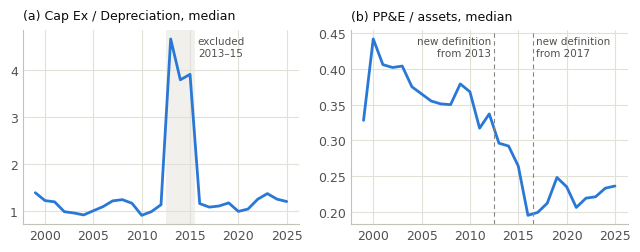

,payout,lev,lev_unadj,lev_book,debt_ebitda,roe,tax,capex_deprec,ppe_assets,capex_assets,div_to_fcfe,div_yield
year,,,,,,,,,,,,
1999,0.247,0.162,0.179,0.456,1.509,0.134,0.376,1.385,0.328,0.103,0.516,0.010
2000,0.182,0.206,0.206,0.460,2.217,0.143,0.259,1.218,0.442,0.089,0.462,0.011
2001,0.122,0.213,0.211,0.442,1.474,0.123,0.244,1.191,0.406,0.079,0.148,0.005
2002,0.159,0.241,0.232,0.433,1.641,0.085,0.209,0.982,0.402,0.072,0.182,0.006
2003,0.291,0.195,0.195,0.430,2.296,0.106,0.225,0.954,0.404,0.066,0.258,0.009
2004,0.170,0.156,0.156,0.410,1.518,0.104,0.203,0.913,0.375,0.058,0.212,0.004
2005,0.261,0.161,0.161,0.374,1.872,0.135,0.192,1.002,0.365,0.059,0.267,0.010
2006,0.247,0.153,0.153,0.385,1.759,0.151,0.189,1.089,0.355,0.063,0.304,0.010
2007,0.234,0.149,0.149,0.380,1.777,0.156,0.186,1.212,0.351,0.071,0.148,0.012


In [6]:
chk_cols = ["payout", "lev", "lev_unadj", "lev_book", "debt_ebitda", "roe", "tax", "capex_deprec", "ppe_assets", "capex_assets",
            "div_to_fcfe", "div_yield"]
yearly_medians = panel_prewin.groupby("year")[[c for c in chk_cols if c in panel_prewin]].median().round(3)
yearly_medians.to_csv(OUTDIR / "tab_data_check_yearly_medians.csv")
crossfile_agreement.round(3).to_csv(OUTDIR / "tab_data_check_crossfile.csv")
alignment_check.to_csv(OUTDIR / "tab_data_check_alignment.csv", index=False)
debt_ebitda_check.to_csv(OUTDIR / "tab_data_check_debt_ebitda.csv", index=False)
# stability of the industry ordering: Spearman correlation of PP&E / assets with the previous year
_w = panel_prewin.pivot_table(index="industry", columns="year", values="ppe_assets")
ppe_rank_stability = pd.Series({y: _w[y - 1].corr(_w[y], method="spearman") for y in _w.columns[1:]},
                               name="rank_corr_with_previous_year").round(3)
ppe_rank_stability.rename_axis("year").to_csv(OUTDIR / "tab_data_check_ppe_rank_stability.csv")
print("PP&E / assets, rank correlation with the previous year (reshuffles in 2013 and 2016):")
print(ppe_rank_stability.to_frame().T.to_string(), "\n")
print("Share of industries where divfund payout = divfcfe D/NI (±5%):")
print(crossfile_agreement.round(2).to_frame().T.to_string(), "\n")
print("Constructed vs reported Debt/EBITDA (non-financial industries, years where Damodaran reports it):")
print(debt_ebitda_check.to_string(index=False), "\n")

fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.6), sharex=True)
ax = axes[0]
ax.axvspan(min(TANG_BREAK_YEARS) - .5, max(TANG_BREAK_YEARS) + .5, color=T["band"], lw=0, zorder=0)
ax.plot(yearly_medians.index, yearly_medians["capex_deprec"], color=T["s1"])
ax.text(max(TANG_BREAK_YEARS) + .8, .97, f"excluded\n{min(TANG_BREAK_YEARS)}–{str(max(TANG_BREAK_YEARS))[2:]}",
        transform=ax.get_xaxis_transform(), ha="left", va="top", fontsize=7.5, color=T["ink2"])
ax.set_title("(a) Cap Ex / Depreciation, median")
ax = axes[1]
ax.plot(yearly_medians.index, yearly_medians["ppe_assets"], color=T["s1"])
for k, y in enumerate(PPE_DEF_CHANGES):   # first label left of its line, the others to the right
    ax.axvline(y - .5, color=T["muted"], lw=.8, ls=(0, (4, 3)))
    ax.text(y - .8 if k == 0 else y - .2, .97, f"new definition\nfrom {y}", transform=ax.get_xaxis_transform(),
            ha="right" if k == 0 else "left", va="top", fontsize=7.5, color=T["ink2"])
ax.set_title("(b) PP&E / assets, median")
fig.tight_layout(); save_fig(fig, OUTDIR / "fig_data_check_tangibility.png", dpi=FIG_DPI, close=False); plt.show()
yearly_medians

## 3 · FRED macro data & the interest-rate regime  <span style="color:gray">(§4.1, §4.3.3)</span>

In [7]:
from paylev.macro import FRED_SERIES, load_fred_snapshot, fetch_fred_live, annualise, add_regime

if FRED_SOURCE == "live":
    try:
        wide = fetch_fred_live(); print("FRED: live download OK")
    except Exception as e:
        print("FRED live download failed:", e, "-> using the pinned snapshot")
        wide = load_fred_snapshot(FRED_SNAPSHOT)
else:
    wide = load_fred_snapshot(FRED_SNAPSHOT)
    print(f"FRED: pinned snapshot {FRED_SNAPSHOT} (set FRED_SOURCE='live' to refresh)")
macro = annualise(wide)

macro = add_regime(macro, HIGH_RATE_RULE, FFR_THRESHOLD)
# Restrict macro to the Damodaran data range (ffr_change is computed on the full series first, so 1999's
# year-on-year change is preserved). This drops any partial current year and the 1998 lead row.
macro = macro[(macro["year"] >= min(years)) & (macro["year"] <= max(years))].reset_index(drop=True)
panel = panel.merge(macro, on="year", how="left")
print("Regime:", HIGH_RATE_RULE, "| high-rate years:",
      sorted(macro.loc[macro.high_rate == 1, "year"].tolist()))
macro.tail(6)

FRED: pinned snapshot data/fred/fred_snapshot.csv (set FRED_SOURCE='live' to refresh)
Regime: threshold | high-rate years: [1999, 2000, 2001, 2005, 2006, 2007, 2023, 2024, 2025]


,year,ffr,t10,cred_spread,gdp_growth,ffr_change,high_rate,high_rate_post2022
21,2020,0.375833,0.894167,1.125833,-2.081378,-1.782500,0,0
22,2021,0.080000,1.442500,0.688333,6.152022,-0.295833,0,0
23,2022,1.683333,2.951667,0.997500,2.524215,1.603333,0,1
24,2023,5.024167,3.957500,1.050833,2.934361,3.340833,1,1
25,2024,5.143333,4.208333,0.709167,2.793187,0.119167,1,1
26,2025,4.212500,4.291667,0.645833,2.106338,-0.930833,1,1


## 4 · Variable definitions  <span style="color:gray">(§4.3)</span>

`payout` (Dividend Payout) · `div_to_fcfe` (Dividends/FCFE) · `div_yield` (dividends ÷ market cap, no earnings in it; used for the ROE check in §9) · `lev` (market D/(D+E), `wacc`) ·
alternative leverage (§9d): `lev_unadj` (market D/(D+E) without capitalised leases), `lev_book` (book D/(D+E)),
`debt_ebitda` (D/(D+E) ÷ EBITDA/EV = debt relative to cash flow) · `tangibility` (**PP&E / total assets**,
percentile rank within the year because the definition changes in 2013 and 2017; the capex-based proxies
Cap Ex/Depreciation, Net Cap Ex/Sales and Capital/Sales are robustness checks in §10) · industry controls `roe`, `tax`, `size`=log(Market Cap), and in §9 `invest` (capital spending / assets, within-year rank: growth and reinvestment) ·
macro controls `gdp_growth`, `cred_spread` · regime `high_rate`, `ffr`, `ffr_change`.

**Note on macro variables.** Anything that varies only over time (the regime dummy, the fed funds rate, GDP growth,
the credit spread) is perfectly collinear with the year fixed effects. In the two-way FE models these enter only
through interactions with industry variables; `fit_panel` prints any regressor the fixed effects absorb. §9 adds an
industry-FE-only specification in which the macro controls and the regime level are estimated directly.

In [8]:
panel["size"] = np.log(panel["mktcap"].where(panel["mktcap"] > 0))
ANALYSIS_VARS = ["payout", "lev", "lev_unadj", "lev_book", "debt_ebitda", "roe", "tax", "size", "tangibility",
                 "gdp_growth", "cred_spread", "high_rate", "ffr", "ffr_change"]
print("Non-null counts:")
print(panel[[c for c in ANALYSIS_VARS if c in panel]].notna().sum().to_string())

Non-null counts:
payout         1920
lev            2102
lev_unadj      2116
lev_book       2099
debt_ebitda    2087
roe            2102
tax            2102
size           2116
tangibility    2116
gdp_growth     2116
cred_spread    2116
high_rate      2116
ffr            2116
ffr_change     2116


## 5 · Descriptive statistics  <span style="color:gray">(§4.4, §6.1)</span>

In [9]:
desc = panel[[c for c in ANALYSIS_VARS if c in panel]].describe().T
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(3)
desc.to_csv(OUTDIR / "tab_descriptives.csv")

# Overall / between / within standard deviation (Stata xtsum logic). The fixed-effects estimates are
# identified only from the WITHIN variation, which is much smaller than the raw ranges suggest.
from paylev.sample import xtsum

sd_decomp = xtsum(panel, ["payout", "lev", "roe", "tax", "size", "tangibility", "div_to_fcfe"])
sd_decomp.to_csv(OUTDIR / "tab_sd_decomposition.csv")
print("Overall / between / within SD:"); print(sd_decomp.to_string()); print()
desc

Overall / between / within SD:
             sd_overall  sd_between  sd_within
payout            0.372       0.221      0.309
lev               0.139       0.129      0.076
roe               0.128       0.078      0.106
tax               0.095       0.080      0.069
size              1.337       1.349      0.587
tangibility       0.289       0.285      0.093
div_to_fcfe       1.560       0.876      1.398



,count,mean,std,min,25%,50%,75%,max
payout,1920.0,0.365,0.372,0.000,0.155,0.279,0.447,2.580
lev,2102.0,0.238,0.139,0.022,0.135,0.211,0.322,0.638
lev_unadj,2116.0,0.230,0.135,0.022,0.131,0.201,0.310,0.634
lev_book,2099.0,0.448,0.161,0.109,0.335,0.448,0.560,0.849
debt_ebitda,2087.0,2.519,1.496,0.434,1.487,2.256,3.134,8.966
roe,2102.0,0.133,0.128,-0.364,0.077,0.135,0.192,0.508
tax,2102.0,0.155,0.095,0.006,0.081,0.140,0.217,0.421
size,2116.0,11.833,1.337,7.461,10.929,11.889,12.802,15.877
tangibility,2116.0,0.506,0.289,0.013,0.256,0.506,0.756,1.000
gdp_growth,2116.0,2.304,1.730,-2.576,1.819,2.524,2.946,6.152


In [10]:
corr_vars = [c for c in ["payout", "lev", "roe", "tax", "size", "tangibility",
                         "gdp_growth", "cred_spread", "ffr"] if c in panel and panel[c].notna().any()]
panel[corr_vars].corr().round(2)

,payout,lev,roe,tax,size,tangibility,gdp_growth,cred_spread,ffr
payout,1.00,0.16,-0.24,-0.23,0.04,0.15,0.01,-0.06,-0.06
lev,0.16,1.00,-0.17,-0.01,-0.37,0.33,-0.08,0.08,-0.09
roe,-0.24,-0.17,1.00,0.15,0.24,0.02,0.09,-0.05,0.02
tax,-0.23,-0.01,0.15,1.00,-0.17,0.09,0.08,0.11,0.22
size,0.04,-0.37,0.24,-0.17,1.00,-0.15,0.02,-0.11,-0.01
tangibility,0.15,0.33,0.02,0.09,-0.15,1.00,0.00,-0.00,0.00
gdp_growth,0.01,-0.08,0.09,0.08,0.02,0.00,1.00,-0.68,0.26
cred_spread,-0.06,0.08,-0.05,0.11,-0.11,-0.00,-0.68,1.00,-0.32
ffr,-0.06,-0.09,0.02,0.22,-0.01,0.00,0.26,-0.32,1.00


## 6 · Baseline panel regression  <span style="color:gray">(§5.2, §6.2)</span>

$$\text{payout}_{it}=\beta\,\text{lev}_{it}+\gamma' X_{it}+\alpha_i+\delta_t+\varepsilon_{it}$$

Industry & year fixed effects, SE clustered by industry. Substitution view → **β < 0**. $X$ = industry-level controls (ROE, tax rate, size); year-only macro variables are absorbed by $\delta_t$.

In [11]:
# Panel OLS with industry and year effects, industry-clustered SE by default (paylev/estimation.py);
# cov="kernel" gives Driscoll-Kraay SE with this notebook's bandwidth.
from paylev.estimation import fit_panel
fit_panel = partial(fit_panel, dk_bandwidth=DK_BANDWIDTH)

# Industry-level controls. Year-only macro controls would be absorbed by the year fixed effects, so they
# are used only in the industry-FE-only robustness specification (§9).
BASE_CONTROLS  = ["roe", "tax", "size"]
MACRO_CONTROLS = [c for c in ["gdp_growth", "cred_spread"] if panel[c].notna().any()]
res_base = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS,
                     title="Baseline: payout ~ leverage + controls (two-way FE)")

=== Baseline: payout ~ leverage + controls (two-way FE) ===
obs=1893  industries=141  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5666     0.2193     2.5832     0.0099      0.1364      0.9968
lev            0.2981     0.1406     2.1194     0.0342      0.0222      0.5739
roe           -1.5916     0.2059    -7.7302     0.0000     -1.9954     -1.1878
tax           -0.4801     0.1650    -2.9095     0.0037     -0.8037     -0.1565
size           0.0049     0.0187     0.2620     0.7934     -0.0317      0.0415
R2(within): 0.165


## 7 · Interaction with the rate regime — H1 & H2  <span style="color:gray">(§5.3, §6.3)</span>

$$\text{payout}_{it}=\beta_1\text{lev}_{it}+\beta_2(\text{lev}_{it}\times\text{HighRate}_t)+\gamma' X_{it}+\alpha_i+\delta_t+\varepsilon_{it}$$

ME of leverage: low-rate $=\beta_1$, high-rate $=\beta_1+\beta_2$. **H2 ⇔ $\beta_2<0$.**

In [12]:
from paylev.estimation import lincom   # linear combination of coefficients: (estimate, SE, t)

panel["lev_x_high"] = panel["lev"] * panel["high_rate"]
res_int = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                    title="H1/H2: payout ~ lev + lev x HighRate + controls (two-way FE)")
if res_int is not None and "lev_x_high" in getattr(res_int, "params", {}):
    lo = lincom(res_int, {"lev": 1}); hi = lincom(res_int, {"lev": 1, "lev_x_high": 1})
    print("\nMarginal effect of leverage on payout:")
    print(f"  low-rate  (b1)    = {lo[0]:+.4f} (SE {lo[1]:.4f}, t {lo[2]:+.2f})")
    print(f"  high-rate (b1+b2) = {hi[0]:+.4f} (SE {hi[1]:.4f}, t {hi[2]:+.2f})")
    print(f"  interaction b2    = {res_int.params['lev_x_high']:+.4f}  <-- H2 (expect < 0)")

=== H1/H2: payout ~ lev + lev x HighRate + controls (two-way FE) ===
obs=1893  industries=141  years=27
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5689     0.2177     2.6136     0.0090      0.1420      0.9958
lev            0.3136     0.1450     2.1625     0.0307      0.0292      0.5979
lev_x_high    -0.0414     0.1413    -0.2927     0.7698     -0.3185      0.2358
roe           -1.5908     0.2055    -7.7394     0.0000     -1.9939     -1.1876
tax           -0.4820     0.1669    -2.8878     0.0039     -0.8094     -0.1546
size           0.0047     0.0184     0.2524     0.8007     -0.0315      0.0408
R2(within): 0.166

Marginal effect of leverage on payout:
  low-rate  (b1)    = +0.3136 (SE 0.1450, t +2.16)
  high-rate (b1+b2) = +0.2722 (SE 0.1739, t +1.57)
  interaction b2    = -0.

=== Continuous regime: payout ~ lev + lev x FFR + controls (two-way FE) ===
obs=1893  industries=141  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5676     0.2175     2.6104     0.0091      0.1411      0.9942
lev            0.3068     0.1545     1.9861     0.0472      0.0038      0.6099
lev_x_ffr     -0.0036     0.0329    -0.1083     0.9138     -0.0681      0.0610
roe           -1.5912     0.2055    -7.7442     0.0000     -1.9941     -1.1882
tax           -0.4806     0.1658    -2.8984     0.0038     -0.8058     -0.1554
size           0.0048     0.0184     0.2593     0.7954     -0.0313      0.0409
R2(within): 0.165


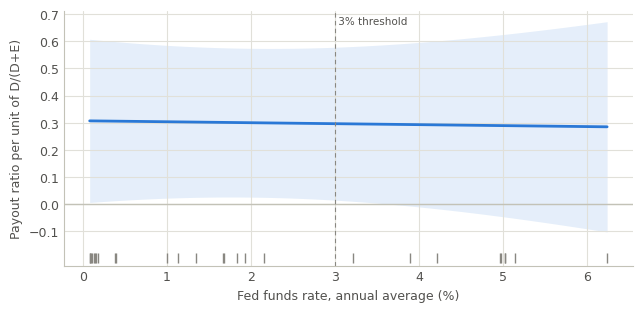

In [13]:
# continuous-regime variant + marginal-effect plot across the rate range
panel["lev_x_ffr"] = panel["lev"] * panel["ffr"]
res_cont = fit_panel(panel, "payout", ["lev", "lev_x_ffr"] + BASE_CONTROLS,
                     title="Continuous regime: payout ~ lev + lev x FFR + controls (two-way FE)")
if res_cont is not None and "lev_x_ffr" in getattr(res_cont, "params", {}):
    rr = np.linspace(panel["ffr"].min(), panel["ffr"].max(), 50)
    pts = [lincom(res_cont, {"lev": 1, "lev_x_ffr": r}) for r in rr]
    me = np.array([p[0] for p in pts]); se = np.array([p[1] for p in pts])
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    ax.fill_between(rr, me - 1.96 * se, me + 1.96 * se, color=T["s1"], alpha=.12, lw=0)
    ax.plot(rr, me, color=T["s1"])
    ax.axhline(0, color=T["base"], lw=1)
    ax.axvline(FFR_THRESHOLD, color=T["muted"], lw=.8, ls=(0, (4, 3)))
    ax.text(FFR_THRESHOLD, .98, f" {FFR_THRESHOLD:g}% threshold", transform=ax.get_xaxis_transform(), fontsize=7.5,
            color=T["ink2"], va="top")
    ylo, yhi = ax.get_ylim(); ticks = [v for v in ax.get_yticks() if ylo <= v <= yhi]
    ax.set_ylim(ylo - .1 * (yhi - ylo), yhi); ax.set_yticks(ticks)     # room for the rug under the band
    ax.plot(macro["ffr"], np.full(len(macro), .03), "|", color=T["muted"], ms=7, mew=1,
            transform=ax.get_xaxis_transform())                          # the rates observed, one tick per year
    ax.set_xlabel("Fed funds rate, annual average (%)")
    ax.set_ylabel("Payout ratio per unit of D/(D+E)")
    fig.tight_layout(); save_fig(fig, OUTDIR / "fig_marginal_effect.png", dpi=FIG_DPI, close=False); plt.show()


## 8 · Asset tangibility as a moderator — H3  <span style="color:gray">(§6.4)</span>

In [14]:
if panel["tangibility"].notna().any():
    panel["lev_x_tang"] = panel["lev"] * panel["tangibility"]
    panel["high_x_tang"] = panel["high_rate"] * panel["tangibility"]
    panel["lev_x_high_x_tang"] = panel["lev"] * panel["high_rate"] * panel["tangibility"]
    # A triple interaction needs every lower-order term, including the tangibility main effect.
    # (high_rate alone is absorbed by the year fixed effects.)
    H3_REGS = ["lev", "tangibility", "lev_x_high", "lev_x_tang", "high_x_tang", "lev_x_high_x_tang"]
    res_h3 = fit_panel(panel, "payout", H3_REGS + BASE_CONTROLS,
        title="H3: triple interaction lev x HighRate x tangibility (two-way FE)")

    # Variant: time-invariant industry tangibility (mean over non-break years) = a structural trait.
    # Its main effect is absorbed by the industry fixed effects; the interactions are identified.
    panel["tang_ind"] = panel.groupby("industry")["tangibility"].transform("mean")
    panel["lev_x_tangI"] = panel["lev"] * panel["tang_ind"]
    panel["high_x_tangI"] = panel["high_rate"] * panel["tang_ind"]
    panel["lev_x_high_x_tangI"] = panel["lev"] * panel["high_rate"] * panel["tang_ind"]
    H3I_REGS = ["lev", "tang_ind", "lev_x_high", "lev_x_tangI", "high_x_tangI", "lev_x_high_x_tangI"]
    res_h3_ti = fit_panel(panel, "payout", H3I_REGS + BASE_CONTROLS,
        title="H3 variant: time-invariant industry tangibility (two-way FE)")

    panel["tang_grp"] = pd.qcut(panel["tangibility"], 3, labels=["low", "mid", "high"], duplicates="drop")
    print("\n--- lev x HighRate by tangibility tercile ---")
    for g in ["low", "high"]:
        sub = panel[panel.tang_grp == g]
        if sub["year"].nunique() >= 3:
            fit_panel(sub, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, title=f"Tangibility = {g}")
else:
    print("H3 inactive: no tangibility.")

=== H3: triple interaction lev x HighRate x tangibility (two-way FE) ===
obs=1893  industries=141  years=27
                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.5247     0.2105     2.4926     0.0128      0.1118      0.9376
lev                   0.3703     0.2569     1.4412     0.1497     -0.1336      0.8742
tangibility           0.1523     0.1404     1.0850     0.2781     -0.1230      0.4277
lev_x_high            0.5797     0.2666     2.1746     0.0298      0.0569      1.1025
lev_x_tang           -0.1685     0.5053    -0.3336     0.7387     -1.1596      0.8225
high_x_tang           0.1724     0.1099     1.5685     0.1169     -0.0432      0.3880
lev_x_high_x_tang    -1.0946     0.4949    -2.2117     0.0271     -2.0652     -0.1239
roe                  -1.6039    

                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  0.5799     0.2056     2.8204     0.0049      0.1766      0.9831
lev                    0.6876     0.3192     2.1537     0.0314      0.0614      1.3137
lev_x_high             0.5468     0.2671     2.0468     0.0408      0.0228      1.0708
lev_x_tangI           -0.7247     0.6075    -1.1928     0.2331     -1.9163      0.4669
high_x_tangI           0.1209     0.1123     1.0765     0.2819     -0.0994      0.3411
lev_x_high_x_tangI    -1.0108     0.4979    -2.0301     0.0425     -1.9873     -0.0342
roe                   -1.5923     0.2062    -7.7210     0.0000     -1.9968     -1.1878
tax                   -0.4911     0.1645    -2.9847     0.0029     -0.8139     -0.1684
size                   0.0027     0.0172   


## 8b · Dividend smoothing: Lintner partial adjustment and H1 in change form  <span style="color:gray">(§6.4, §7.1)</span>

**Lintner (1956).** Firms move dividends only part of the way toward a target share of earnings each year:
$\Delta D_{it} = \text{SOA}\,(r\,E_{it} - D_{i,t-1})$. Scaling by last year's market cap (so large and small
industries are comparable) gives

$$\frac{\Delta D_{it}}{MC_{i,t-1}}=\beta_E\,\frac{E_{it}}{MC_{i,t-1}}+\beta_D\,\frac{D_{i,t-1}}{MC_{i,t-1}}+\alpha_i+\delta_t+\varepsilon_{it},
\qquad \text{SOA}=-\beta_D,\quad r=\beta_E/\text{SOA}.$$

A low speed of adjustment (SOA) means sticky dividends, the proposed explanation for the null in §7.

**H1 as stated is about changes** ("industries with higher leverage *reduce* dividends more during rate-hiking
cycles"). Adding last year's leverage and its interaction with the regime to the change equation tests it directly:
H1 ⇔ $\text{lev}_{t-1}\times\text{Regime}<0$. Three regime definitions: the high-rate dummy, hiking years
(fed funds up ≥ 25bp), and the continuous change in the fed funds rate.

**Estimation notes.** With a lagged dependent variable, industry fixed effects bias the persistence coefficient
downward (Nickell, 1981), so the within estimator *overstates* SOA, while pooled OLS without industry effects
*understates* it; the true value lies between the two (Bond, 2002). Dollar dividends and net income come from
`divfcfe` (net income excluded in the years flagged by the §2 cross-file check); industries merged by the rename
map are summed. Lags require the previous calendar year (no gap bridging), and 2013 is dropped from these models because
the 2012→2013 change crosses Damodaran's reclassification: industry dividends jump by a median 42% that year versus
10–20% in other years, which reflects firms moving between industries rather than dividend decisions.


In [15]:

# ---- dollar frame ($m): dividends & net income (divfcfe), market cap (divfund).
#      Industries merged by the rename map are SUMMED here (the ratio panel averages them).
usd = raw[["industry", "year", "div_usd", "ni_usd", "mktcap"]].copy()
usd["industry"] = usd["industry"].replace(INDUSTRY_RENAME)
usd = (usd[usd["industry"].isin(panel["industry"])]
       .groupby(["industry", "year"], as_index=False)[["div_usd", "ni_usd", "mktcap"]].sum(min_count=1))
L = usd.merge(panel[["industry", "year", "payout", "lev", "roe", "tax", "size",
                     "high_rate", "ffr_change", "in_core"]], on=["industry", "year"], how="inner")

# gap-safe one-year lags: an industry missing year t-1 gets no lag
_lag = L[["industry", "year", "div_usd", "mktcap", "lev", "payout"]].copy(); _lag["year"] += 1
L = L.merge(_lag.rename(columns={c: c + "_l1" for c in ["div_usd", "mktcap", "lev", "payout"]}),
            on=["industry", "year"], how="left")
L["dD"] = (L["div_usd"] - L["div_usd_l1"]) / L["mktcap_l1"]      # change in dividends
L["E"]  = L["ni_usd"] / L["mktcap_l1"]                            # current earnings
L["Dl"] = L["div_usd_l1"] / L["mktcap_l1"]                        # last year's dividends
L.loc[L["year"].isin(DIVFCFE_BAD_YEARS), ["dD", "E"]] = np.nan    # net income unreliable there (§2 check)
L.loc[L["year"] == RECLASS_YEAR, ["dD", "payout_l1", "lev_l1"]] = np.nan   # t-1 -> t crosses the 2013 reclassification
L = winsorize(L, ["dD", "E", "Dl"])
L["hike"] = (L["ffr_change"] >= HIKE_THRESHOLD).astype(int)
for a, b in [("E", "high_rate"), ("Dl", "high_rate"), ("lev_l1", "high_rate"),
             ("lev_l1", "hike"), ("lev_l1", "ffr_change")]:
    L[f"{a}_x_{b}"] = L[a] * L[b]
print("Hiking years (fed funds up >= %.2fpp):" % HIKE_THRESHOLD,
      sorted(int(y) for y in L.loc[L["hike"] == 1, "year"].unique()), "\n")

lint = {}
lint["L1_within"] = fit_panel(L, "dD", ["E", "Dl"], title="L1 Lintner, two-way FE (SOA upper bound)")
lint["L1_pooled"] = fit_panel(L, "dD", ["E", "Dl"], entity=False,
                              title="L1 Lintner, year FE only (SOA lower bound)")
lint["L2_regime"] = fit_panel(L, "dD", ["E", "Dl", "E_x_high_rate", "Dl_x_high_rate"],
                              title="L2 Smoothing by regime")
H1C = ["E", "Dl", "lev_l1"]
lint["L3_high"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_high_rate"], title="L3 H1 in change form: high-rate years")
lint["L3_hike"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_hike"], title="L3 H1 in change form: hiking years")
lint["L3_dffr"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_ffr_change"], title="L3 H1 in change form: change in FFR")
lint["L3_core"]  = fit_panel(L[L["in_core"]], "dD", H1C + ["lev_l1_x_high_rate"],
                             title="L3 H1 in change form: high-rate years, stable core")
lint["R_within"] = fit_panel(L, "payout", ["payout_l1"] + BASE_CONTROLS, title="Payout-ratio persistence, two-way FE")
lint["R_pooled"] = fit_panel(L, "payout", ["payout_l1"] + BASE_CONTROLS, entity=False,
                             title="Payout-ratio persistence, year FE only")

# ---- summary
soa_hi, soa_lo = -lint["L1_within"].params["Dl"], -lint["L1_pooled"].params["Dl"]
target = lint["L1_pooled"].params["E"] / soa_lo
rho_lo, rho_hi = lint["R_within"].params["payout_l1"], lint["R_pooled"].params["payout_l1"]
print(f"\nSpeed of adjustment of dividends: between {soa_lo:.2f} and {soa_hi:.2f} per year "
      f"(dividend persistence {1 - soa_hi:.2f}-{1 - soa_lo:.2f}); target payout (pooled) = {target:.2f}")
print(f"Persistence of the payout RATIO: {rho_lo:.2f}-{rho_hi:.2f}")

KEYS = [("L1_within", "Dl", "Lintner, two-way FE"), ("L1_pooled", "Dl", "Lintner, year FE only"),
        ("L2_regime", "Dl_x_high_rate", "Smoothing x high-rate"), ("L2_regime", "E_x_high_rate", "Earnings x high-rate"),
        ("L3_high", "lev_l1_x_high_rate", "H1 change form: high-rate"),
        ("L3_hike", "lev_l1_x_hike", "H1 change form: hiking year"),
        ("L3_dffr", "lev_l1_x_ffr_change", "H1 change form: change in FFR"),
        ("L3_core", "lev_l1_x_high_rate", "H1 change form: high-rate, stable core"),
        ("R_within", "payout_l1", "Payout-ratio persistence, two-way FE"),
        ("R_pooled", "payout_l1", "Payout-ratio persistence, year FE only")]
lint_tbl = pd.DataFrame([{"model": lab, "term": t, "coef": lint[k].params[t], "se": lint[k].std_errors[t],
                          "p": lint[k].pvalues[t], "N": int(lint[k].nobs)} for k, t, lab in KEYS]).round(4)
lint_tbl.to_csv(OUTDIR / "tab_lintner.csv", index=False)
lint_tbl


Hiking years (fed funds up >= 0.25pp): [2000, 2005, 2006, 2016, 2017, 2018, 2019, 2022, 2023] 

=== L1 Lintner, two-way FE (SOA upper bound) ===
obs=1771  industries=131  years=23


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0050     0.0005     10.518     0.0000      0.0040      0.0059
E              0.0259     0.0066     3.8983     0.0001      0.0129      0.0389
Dl            -0.3624     0.0278    -13.012     0.0000     -0.4170     -0.3077
R2(within): 0.162
=== L1 Lintner, year FE only (SOA lower bound) ===
obs=1771  industries=131  years=23
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0011     0.0004     3.0345     0.0024      0.0004      0.0018
E              0.0268     0.0052     5.1063     0.0000      0.0165      0.0371
Dl            -0.0943     0

                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  0.0040     0.0007     5.6953     0.0000      0.0026      0.0053
E                      0.0273     0.0064     4.2610     0.0000      0.0147      0.0398
Dl                    -0.3841     0.0296    -12.975     0.0000     -0.4422     -0.3261
lev_l1                 0.0048     0.0033     1.4623     0.1439     -0.0016      0.0111
lev_l1_x_high_rate     0.0016     0.0039     0.4192     0.6751     -0.0060      0.0093
R2(within): 0.161
=== L3 H1 in change form: hiking years ===
obs=1771  industries=131  years=23


                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------
const             0.0039     0.0007     5.5432     0.0000      0.0025      0.0052
E                 0.0273     0.0064     4.2404     0.0000      0.0147      0.0400
Dl               -0.3834     0.0299    -12.839     0.0000     -0.4419     -0.3248
lev_l1            0.0049     0.0031     1.5592     0.1191     -0.0013      0.0110
lev_l1_x_hike     0.0015     0.0023     0.6669     0.5050     -0.0029      0.0060
R2(within): 0.166
=== L3 H1 in change form: change in FFR ===
obs=1771  industries=131  years=23
                                  Parameter Estimates                                  
                     Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.7795     0.2290     3.4045     0.0007      0.3304      1.2286
payout_l1      0.1320     0.0438     3.0124     0.0026      0.0461      0.2180
roe           -1.5502     0.2248    -6.8945     0.0000     -1.9912     -1.1091
tax           -0.4263     0.1824    -2.3366     0.0196     -0.7841     -0.0684
size          -0.0124     0.0197    -0.6305     0.5285     -0.0509      0.0262
R2(within): 0.185
=== Payout-ratio persistence, year FE only ===
obs=1651  industries=132  years=25
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.3053     0.122

,model,term,coef,se,p,N
0,"Lintner, two-way FE",Dl,-0.3624,0.0278,0.0000,1771
1,"Lintner, year FE only",Dl,-0.0943,0.0270,0.0005,1771
2,Smoothing x high-rate,Dl_x_high_rate,0.0336,0.0391,0.3903,1771
3,Earnings x high-rate,E_x_high_rate,0.0044,0.0123,0.7221,1771
4,H1 change form: high-rate,lev_l1_x_high_rate,0.0016,0.0039,0.6751,1771
5,H1 change form: hiking year,lev_l1_x_hike,0.0015,0.0023,0.5050,1771
6,H1 change form: change in FFR,lev_l1_x_ffr_change,0.0006,0.0009,0.5179,1771
7,"H1 change form: high-rate, stable core",lev_l1_x_high_rate,0.0022,0.0030,0.4647,1026
8,"Payout-ratio persistence, two-way FE",payout_l1,0.1320,0.0438,0.0026,1651
9,"Payout-ratio persistence, year FE only",payout_l1,0.4263,0.0553,0.0000,1651


## 9 · Robustness  <span style="color:gray">(§5.5, §6.5)</span>

Alt payout measures · **stable-core sample** (immune to the 2013 reclassification) · **post-2022 regime**
definition · two-way clustering · ex-COVID · **ex-financial crisis (2008–09)** · **growth / reinvestment control** · lagged leverage · **industry FE only with macro controls** ·
**ROE mechanical-link check (dividend yield as an earnings-free DV)** · **backward elimination of insignificant controls** · **H3 in the stable core** · **payout as reported (incl. non-positive earnings)** · **Driscoll–Kraay SE** · **first differences** ·
**weighting by number of firms** (the last three also stress-test the leverage coefficient, §9c) ·
**alternative leverage measures**: without leases, book, Debt/EBITDA (§9d) · **H3 sensitivity** (inference,
sample, continuous rate).

In [16]:
robust = {}
# (a) stable core
print(">>> Stable core (industries present >= MIN_YEARS_CORE years)")
robust["core"] = fit_panel(panel[panel.in_core], "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                           title=f"Stable core ({len(CORE)} industries)")
# (b) post-2022 regime definition
pp = panel.copy(); pp["lev_x_high"] = pp["lev"] * pp["high_rate_post2022"]
print("\n>>> Post-2022 binary regime")
robust["post2022"] = fit_panel(pp, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                               title="Regime = post-2022 binary")
# (c) alternative payout
for dv_alt in ["div_to_fcfe", "totpayout_ni", "div_yield"]:
    if dv_alt in panel and panel[dv_alt].notna().any():
        print(f"\n>>> Alt payout: {dv_alt}")
        robust[dv_alt] = fit_panel(panel, dv_alt, ["lev", "lev_x_high"] + BASE_CONTROLS, title=f"DV={dv_alt}")
# (d) two-way clustering
print("\n>>> Two-way clustered SE")
robust["twoway"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                             cluster_time=True, title="Two-way clustering")
# (e) ex-COVID
print("\n>>> Excluding COVID years", COVID_YEARS)
robust["noCovid"] = fit_panel(panel[~panel.year.isin(COVID_YEARS)], "payout",
                              ["lev", "lev_x_high"] + BASE_CONTROLS, title="Excl. COVID")
# (e2) excluding the financial crisis
print("\n>>> Excluding the financial-crisis years", GFC_YEARS)
robust["noGFC"] = fit_panel(panel[~panel.year.isin(GFC_YEARS)], "payout",
                            ["lev", "lev_x_high"] + BASE_CONTROLS, title="Excl. financial crisis")
# (e3) growth / reinvestment control: industries that invest heavily may both borrow more and pay out less
print("\n>>> Growth / reinvestment control (capital spending intensity, within-year rank)")
robust["growth"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS + ["invest"],
                             title="Interaction + capital spending intensity")
# (f) lagged leverage
pl = panel.sort_values(["industry", "year"]).copy()
pl["lev_lag"] = pl.groupby("industry")["lev"].shift(1)
pl["lev_lag_x_high"] = pl["lev_lag"] * pl["high_rate"]
if pl["lev_lag"].notna().any():
    print("\n>>> Lagged leverage")
    robust["lagged"] = fit_panel(pl, "payout", ["lev_lag", "lev_lag_x_high"] + BASE_CONTROLS,
                                 title="Lagged leverage")

# (g) industry FE only: the macro controls and the regime level are estimable here (no year FE),
#     so errors are clustered by industry AND year.
print("\n>>> Industry FE only, with macro controls and the regime level")
robust["indFE_macro"] = fit_panel(panel, "payout",
    ["lev", "high_rate", "lev_x_high"] + BASE_CONTROLS + MACRO_CONTROLS,
    time=False, cluster_time=True, title="Industry FE + macro controls (no year FE), two-way clustered")

# (h) ROE mechanical-link check. The payout ratio is D/NI and ROE is NI/E, so both contain net income.
#     Dividends/FCFE does not solve this (FCFE = NI - net capex - change in working capital + net borrowing).
#     Dividend yield (D / market cap) contains no earnings, so the ROE coefficient there is free of the
#     accounting link. Caveat: yield and leverage D/(D+E) both contain market equity, so the LEVERAGE
#     coefficient in the yield regression is itself partly mechanical; the check is about ROE only.
print("\n>>> ROE mechanical-link check: interaction model without ROE")
robust["noROE"] = fit_panel(panel, "payout", ["lev", "lev_x_high", "tax", "size"],
                            title="Interaction without ROE")
_roe_rows = []
for dv_, res_, ni_in in [("payout (D/NI)", res_int, "yes"), ("Dividends/FCFE", robust.get("div_to_fcfe"), "yes (via FCFE)"),
                         ("Dividend yield (D/MC)", robust.get("div_yield"), "no")]:
    if res_ is not None and "roe" in res_.params:
        _roe_rows.append({"dependent variable": dv_, "net income in DV": ni_in, "roe_coef": res_.params["roe"],
                          "se": res_.std_errors["roe"], "p": res_.pvalues["roe"], "N": int(res_.nobs)})
roe_check = pd.DataFrame(_roe_rows).round(4)
roe_check.to_csv(OUTDIR / "tab_roe_check.csv", index=False)
print("\nROE coefficient by dependent variable (interaction model, two-way FE):")
print(roe_check.to_string(index=False))

# (i) Backward elimination a posteriori: repeatedly drop the least significant CONTROL with p > 0.05.
#     The hypothesis terms (lev, lev_x_high) are never dropped.
print("\n>>> Backward elimination of insignificant controls (a posteriori, 5%)")
keep = list(BASE_CONTROLS)
while keep:
    r_ = fit_panel(panel, "payout", ["lev", "lev_x_high"] + keep, title=f"Elimination step: controls={keep}")
    pv = r_.pvalues[keep]
    if pv.max() <= 0.05:
        break
    print(f"   -> dropping {pv.idxmax()} (p={pv.max():.3f})\n")
    keep.remove(pv.idxmax())
robust["elimination"] = r_
print("Controls retained by elimination:", keep)

# (j) H3 in the stable core
if "res_h3" in globals():
    print("\n>>> H3 in the stable core")
    robust["H3_core"] = fit_panel(panel[panel.in_core], "payout", H3_REGS + BASE_CONTROLS,
                                  title="H3: stable core")

# (k) payout as reported, including industry-years with non-positive earnings
print("\n>>> Payout as reported, including industry-years with ROE <= 0")
robust["payout_all"] = fit_panel(panel, "payout_all", ["lev", "lev_x_high"] + BASE_CONTROLS,
                                 title="DV = payout as reported (incl. ROE <= 0)")

# ---- Stress tests of the leverage-payout relation and of H2 (§9c). For each, the baseline model gives the
#      leverage coefficient and the interaction model gives beta2.
stress_base = {"main": res_base}
stress_base["noGFC"] = fit_panel(panel[~panel.year.isin(GFC_YEARS)], "payout", ["lev"] + BASE_CONTROLS,
                                 title="Baseline, excl. financial crisis")
stress_base["growth"] = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS + ["invest"],
                                  title="Baseline + capital spending intensity")
# (l) Driscoll-Kraay SE: robust to cross-sectional dependence (common shocks hit all industries in a year)
#     and to serial correlation up to DK_BANDWIDTH lags.
print("\n>>> Driscoll-Kraay standard errors")
stress_base["dk"] = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS, cov="kernel",
                              title="Baseline, Driscoll-Kraay SE")
robust["dk"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, cov="kernel",
                         title="Interaction, Driscoll-Kraay SE")
stress_base["twoway"] = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS, cluster_time=True,
                                  title="Baseline, two-way clustered SE")

# (m) First differences: eliminate the industry effects by differencing instead of demeaning. Gap-safe
#     (previous calendar year only), with year effects; 2013 dropped (the change crosses the reclassification).
_s = panel.sort_values(["industry", "year"])
_g = _s.groupby("industry")
_consec = _g["year"].shift(1) == _s["year"] - 1
fd = _s[["industry", "year", "in_core"]].copy()
for v in ["payout", "lev", "lev_x_high"] + BASE_CONTROLS:
    fd["d_" + v] = (_s[v] - _g[v].shift(1)).where(_consec)
fd.loc[fd["year"] == RECLASS_YEAR, [c for c in fd.columns if c.startswith("d_")]] = np.nan
D_CONTROLS = ["d_" + c for c in BASE_CONTROLS]
print("\n>>> First differences (with year effects)")
stress_base["fd"] = fit_panel(fd, "d_payout", ["d_lev"] + D_CONTROLS, entity=False,
                              title="Baseline, first differences")
robust["fd"] = fit_panel(fd, "d_payout", ["d_lev", "d_lev_x_high"] + D_CONTROLS, entity=False,
                         title="Interaction, first differences")

# (n) Weighted by the number of firms in the industry (large industries count more)
print("\n>>> Weighted by number of firms")
stress_base["wls"] = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS, weights="n_firms",
                               title="Baseline, weighted by number of firms")
robust["wls"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, weights="n_firms",
                          title="Interaction, weighted by number of firms")

# (o) Alternative leverage measures (§9d). Each replaces `lev` in the baseline and interaction models; `m_x_high`
#     is the measure times the high-rate dummy. Debt/EBITDA is also interacted with the fed funds rate: with year
#     effects, FFR x Debt/EBITDA is the part of an interest-burden proxy (rate x debt / cash flow) that differs
#     across industries. Caveat: Debt/EBITDA and the payout ratio both contain earnings, so the dividend yield
#     (no earnings in it) is reported as a second dependent variable.
ALT_LEV = {"lev": "Market D/(D+E), main (leases from 2013)", "lev_unadj": "Market D/(D+E), without leases",
           "lev_book": "Book D/(D+E)", "debt_ebitda": "Debt / EBITDA"}
alt_base, alt_int = {}, {}
for v, lab in ALT_LEV.items():
    d = panel.assign(m_x_high=panel[v] * panel["high_rate"], m_x_ffr=panel[v] * panel["ffr"])
    print(f"\n>>> Leverage measure: {lab}")
    alt_base[v] = fit_panel(d, "payout", [v] + BASE_CONTROLS, title=f"Baseline, leverage = {lab}")
    alt_int[v] = fit_panel(d, "payout", [v, "m_x_high"] + BASE_CONTROLS, title=f"Interaction, leverage = {lab}")
    if v != "lev":
        robust[v] = alt_int[v]
    if v == "debt_ebitda":
        alt_int["debt_ebitda_ffr"] = fit_panel(d, "payout", [v, "m_x_ffr"] + BASE_CONTROLS,
                                               title="Debt/EBITDA x fed funds rate (interest-burden proxy)")
        alt_base["debt_ebitda_yield"] = fit_panel(d, "div_yield", [v] + BASE_CONTROLS,
                                                  title="DV = dividend yield, baseline, Debt/EBITDA")
        alt_int["debt_ebitda_yield"] = fit_panel(d, "div_yield", [v, "m_x_high"] + BASE_CONTROLS,
                                                 title="DV = dividend yield, Debt/EBITDA x high-rate")

# (p) Sensitivity of the H3 triple term (primary tangibility measure) to inference, sample and regime definition
if "res_h3" in globals():
    H3M = H3_REGS + BASE_CONTROLS
    print("\n>>> H3 sensitivity")
    h3_rob = {"Main (industry-clustered SE)": res_h3,
              "Driscoll-Kraay SE": fit_panel(panel, "payout", H3M, cov="kernel", title="H3, Driscoll-Kraay SE"),
              "Two-way clustered SE": fit_panel(panel, "payout", H3M, cluster_time=True, title="H3, two-way clustered SE"),
              "Excl. 2020-21": fit_panel(panel[~panel.year.isin(COVID_YEARS)], "payout", H3M, title="H3, excl. COVID"),
              "Excl. 2008-09": fit_panel(panel[~panel.year.isin(GFC_YEARS)], "payout", H3M, title="H3, excl. GFC"),
              "Weighted by number of firms": fit_panel(panel, "payout", H3M, weights="n_firms", title="H3, weighted"),
              # capital spending intensity is correlated with PP&E: does the triple term survive holding it fixed?
              "Growth control (capex intensity)": fit_panel(panel, "payout", H3M + ["invest"],
                                                            title="H3 + capital spending intensity"),
              "Stable core": robust.get("H3_core")}
    _c = panel.assign(lev_x_high=panel.lev * panel.ffr, high_x_tang=panel.ffr * panel.tangibility,
                      lev_x_high_x_tang=panel.lev * panel.ffr * panel.tangibility)
    h3_rob["Continuous rate (FFR, per pp)"] = fit_panel(_c, "payout", H3M, title="H3 with the fed funds rate")
    h3_rob_tbl = pd.DataFrame([{"specification": k, "triple_coef": r.params["lev_x_high_x_tang"],
                                "se": r.std_errors["lev_x_high_x_tang"], "p": r.pvalues["lev_x_high_x_tang"],
                                "N": int(r.nobs)} for k, r in h3_rob.items() if r is not None]).round(4)
    h3_rob_tbl.to_csv(OUTDIR / "tab_H3_robustness.csv", index=False)
    print("\nH3 triple term across specifications:"); print(h3_rob_tbl.to_string(index=False))


>>> Stable core (industries present >= MIN_YEARS_CORE years)
=== Stable core (46 industries) ===
obs=1089  industries=46  years=27
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5958     0.2741     2.1737     0.0300      0.0579      1.1336
lev            0.4767     0.1505     3.1663     0.0016      0.1813      0.7721
lev_x_high    -0.0887     0.1759    -0.5044     0.6141     -0.4340      0.2565
roe           -1.5741     0.2521    -6.2429     0.0000     -2.0689     -1.0793
tax           -0.4616     0.1957    -2.3589     0.0185     -0.8456     -0.0776
size           0.0024     0.0230     0.1055     0.9160     -0.0427      0.0476
R2(within): 0.177

>>> Post-2022 binary regime
=== Regime = post-2022 binary ===
obs=1893  industries=141  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.6002     0.2118     2.8338     0.0047      0.1848      1.0155
lev            0.3129     0.1377     2.2722     0.0232      0.0428      0.5831
lev_x_high    -0.1656     0.2647    -0.6256     0.5317     -0.6848      0.3536
roe           -1.5901     0.2062    -7.7125     0.0000     -1.9945     -1.1857
tax           -0.4836     0.1655    -2.9215     0.0035     -0.8083     -0.1589
size           0.0023     0.0179     0.1267     0.8992     -0.0328      0.0373
R2(within): 0.155

>>> Alt payout: div_to_fcfe


=== DV=div_to_fcfe ===
obs=1601  industries=136  years=25
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.9809     1.2761     0.7686     0.4422     -1.5224      3.4842
lev            1.0174     0.7367     1.3811     0.1675     -0.4277      2.4626
lev_x_high    -0.2498     0.6578    -0.3798     0.7042     -1.5402      1.0406
roe           -2.8512     0.7811    -3.6505     0.0003     -4.3834     -1.3191
tax           -1.6559     1.7107    -0.9680     0.3332     -5.0117      1.6999
size           0.0196     0.1014     0.1931     0.8469     -0.1793      0.2185
R2(within): 0.043

>>> Alt payout: totpayout_ni
=== DV=totpayout_ni ===
obs=894  industries=91  years=13
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0210     0.0063     3.3497     0.0008      0.0087      0.0333
lev            0.0281     0.0051     5.5131     0.0000      0.0181      0.0381
lev_x_high     0.0066     0.0042     1.5754     0.1153     -0.0016      0.0149
roe            0.0039     0.0021     1.8124     0.0701     -0.0003      0.0081
tax            0.0023     0.0035     0.6397     0.5225     -0.0047      0.0092
size          -0.0013     0.0005    -2.4198     0.0156     -0.0023     -0.0002
R2(within): 0.145

>>> Two-way clustered SE
=== Two-way clustering ===
obs=1893  industries=141  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5689     0.1951     2.9162     0.0036      0.1863      0.9515
lev            0.3136     0.1479     2.1194     0.0342      0.0234      0.6037
lev_x_high    -0.0414     0.1376    -0.3004     0.7639     -0.3113      0.2286
roe           -1.5908     0.2109    -7.5412     0.0000     -2.0045     -1.1770
tax           -0.4820     0.1524    -3.1625     0.0016     -0.7810     -0.1831
size           0.0047     0.0159     0.2931     0.7695     -0.0265      0.0358
R2(within): 0.166

>>> Excluding COVID years [2020, 2021]
=== Excl. COVID ===
obs=1770  industries=141  years=25
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------

...

                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const           0.0487     0.0085     5.7464     0.0000      0.0321      0.0653
debt_ebitda -6.833e-05     0.0003    -0.1972     0.8437     -0.0007      0.0006
m_x_high        0.0001     0.0005     0.2058     0.8370     -0.0009      0.0011
roe         -8.368e-05     0.0023    -0.0359     0.9713     -0.0046      0.0045
tax            -0.0002     0.0041    -0.0505     0.9597     -0.0082      0.0078
size           -0.0029     0.0007    -4.0305     0.0001     -0.0043     -0.0015
R2(within): 0.063

>>> H3 sensitivity
=== H3, Driscoll-Kraay SE ===
obs=1893  industries=141  years=27
                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----

                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.5247     0.1815     2.8917     0.0039      0.1688      0.8806
lev                   0.3703     0.2267     1.6334     0.1026     -0.0743      0.8149
tangibility           0.1523     0.1525     0.9988     0.3181     -0.1468      0.4515
lev_x_high            0.5797     0.3184     1.8207     0.0688     -0.0448      1.2041
lev_x_tang           -0.1685     0.4816    -0.3500     0.7264     -1.1131      0.7760
high_x_tang           0.1724     0.0990     1.7408     0.0819     -0.0218      0.3667
lev_x_high_x_tang    -1.0946     0.4812    -2.2746     0.0231     -2.0384     -0.1507
roe                  -1.6039     0.2050    -7.8243     0.0000     -2.0059     -1.2018
tax                  -0.4884     0.1555    -3.1410    

                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.4901     0.2304     2.1273     0.0335      0.0382      0.9419
lev                   0.2301     0.2404     0.9573     0.3386     -0.2414      0.7017
tangibility           0.0673     0.1460     0.4611     0.6448     -0.2191      0.3537
lev_x_high            0.6251     0.2803     2.2301     0.0259      0.0753      1.1748
lev_x_tang            0.1291     0.5421     0.2381     0.8118     -0.9342      1.1924
high_x_tang           0.2174     0.1212     1.7941     0.0730     -0.0203      0.4550
lev_x_high_x_tang    -1.2407     0.5520    -2.2478     0.0247     -2.3234     -0.1581
roe                  -1.6544     0.2089    -7.9191     0.0000     -2.0641     -1.2446
tax                  -0.5410     0.1557    -3.4752    

                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.7238     0.3101     2.3337     0.0197      0.1155      1.3321
lev                   0.5800     0.2468     2.3501     0.0189      0.0959      1.0641
tangibility           0.1038     0.1683     0.6171     0.5373     -0.2262      0.4339
lev_x_high            0.3953     0.1854     2.1320     0.0331      0.0316      0.7589
lev_x_tang           -0.4936     0.6103    -0.8089     0.4187     -1.6907      0.7034
high_x_tang           0.1361     0.1107     1.2295     0.2191     -0.0810      0.3531
lev_x_high_x_tang    -0.9054     0.4197    -2.1574     0.0311     -1.7284     -0.0823
roe                  -1.7631     0.2494    -7.0686     0.0000     -2.2523     -1.2739
tax                  -0.5303     0.2032    -2.6100    

                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.5286     0.2120     2.4930     0.0128      0.1127      0.9444
lev                   0.2555     0.2971     0.8599     0.3900     -0.3273      0.8383
tangibility           0.1310     0.1448     0.9047     0.3657     -0.1530      0.4150
lev_x_high            0.1321     0.0633     2.0858     0.0371      0.0079      0.2563
lev_x_tang            0.0080     0.5509     0.0145     0.9885     -1.0725      1.0885
high_x_tang           0.0325     0.0237     1.3717     0.1703     -0.0140      0.0790
lev_x_high_x_tang    -0.2311     0.1096    -2.1089     0.0351     -0.4461     -0.0162
roe                  -1.6054     0.2055    -7.8124     0.0000     -2.0084     -1.2024
tax                  -0.4874     0.1642    -2.9675    

In [17]:

# Robustness summary (Appendix C): the regime-interaction term in every specification
KEY = {"lagged": "lev_lag_x_high", "H3_core": "lev_x_high_x_tang", "fd": "d_lev_x_high",
       "lev_unadj": "m_x_high", "lev_book": "m_x_high", "debt_ebitda": "m_x_high"}
LABEL = {"core": "Stable core", "post2022": "Regime = post-2022", "div_to_fcfe": "DV = Dividends/FCFE",
         "totpayout_ni": "DV = (Div+Buybacks)/NI", "div_yield": "DV = Dividend yield", "twoway": "Two-way clustered SE", "noCovid": "Excl. 2020-21", "noGFC": "Excl. 2008-09",
         "growth": "Growth control (capex intensity)",
         "lagged": "Lagged leverage", "indFE_macro": "Industry FE + macro controls",
         "noROE": "Without ROE", "elimination": "Backward elimination",
         "payout_all": "Payout incl. non-positive earnings", "dk": "Driscoll-Kraay SE",
         "fd": "First differences", "wls": "Weighted by number of firms",
         "lev_unadj": "Leverage without leases", "lev_book": "Book leverage",
         "debt_ebitda": "Debt/EBITDA (per unit, not per SD)", "H3_core": "H3 triple term, stable core"}
rows = [{"specification": "Main (two-way FE)", "term": "lev_x_high",
         "coef": res_int.params["lev_x_high"], "se": res_int.std_errors["lev_x_high"],
         "p": res_int.pvalues["lev_x_high"], "N": int(res_int.nobs)}]
for k, r in robust.items():
    if r is None:
        continue
    term = KEY.get(k, "lev_x_high")
    if term in r.params:
        rows.append({"specification": LABEL.get(k, k), "term": term, "coef": r.params[term],
                     "se": r.std_errors[term], "p": r.pvalues[term], "N": int(r.nobs)})
rob_tbl = pd.DataFrame(rows).round(4)
rob_tbl.to_csv(OUTDIR / "tab_robustness_summary.csv", index=False)
rob_tbl


,specification,term,coef,se,p,N
0,Main (two-way FE),lev_x_high,-0.0414,0.1413,0.7698,1893
1,Stable core,lev_x_high,-0.0887,0.1759,0.6141,1089
2,Regime = post-2022,lev_x_high,-0.1656,0.2647,0.5317,1893
3,DV = Dividends/FCFE,lev_x_high,-0.2498,0.6578,0.7042,1601
4,DV = (Div+Buybacks)/NI,lev_x_high,-0.4497,1.0514,0.6690,894
5,DV = Dividend yield,lev_x_high,0.0066,0.0042,0.1153,2086
6,Two-way clustered SE,lev_x_high,-0.0414,0.1376,0.7639,1893
7,Excl. 2020-21,lev_x_high,-0.0692,0.1493,0.6429,1770
8,Excl. 2008-09,lev_x_high,-0.0479,0.1475,0.7455,1746
9,Growth control (capex intensity),lev_x_high,-0.0681,0.1432,0.6345,1893


### 9b · How large an effect can we rule out?  <span style="color:gray">(§6.5, §7.1)</span>

A non-significant estimate is only informative if the test could have detected an effect of economically
relevant size. For the H2 interaction in each payout-ratio specification the table reports:

- the **95% confidence interval** of β₂: regime effects outside it are rejected at 5%;
- the **minimum detectable effect** at 5% significance and 80% power, MDE = (z₀.₉₇₅ + z₀.₈₀)·SE ≈ 2.8·SE
  (Bloom, 1995): the smallest true β₂ the test would detect four times out of five;
- the smallest **equivalence margin** δ for which two one-sided tests (TOST; Schuirmann, 1987; Lakens, 2017)
  reject |β₂| ≥ δ at 5%, i.e. the largest absolute bound of the 90% interval.

Coefficients are converted into payout-ratio units for a one-standard-deviation difference in leverage
(overall SD, i.e. across industries, as H2 compares more and less levered industries; the within-industry SD
is shown for reference). `EQUIV_MARGIN` in the configuration sets the effect regarded as economically
negligible for the yes/no equivalence column.

In [18]:
from scipy import stats
Z95, Z90, Z80 = stats.norm.ppf(0.975), stats.norm.ppf(0.95), stats.norm.ppf(0.80)
SD_LEV   = float(sd_decomp.loc["lev", "sd_overall"])   # across industries (used for the payout conversion)
SD_LEV_W = float(sd_decomp.loc["lev", "sd_within"])    # within industries (reference)
MEAN_PAYOUT = float(panel["payout"].mean())

PAYOUT_SPECS = ["Main (two-way FE)", "Stable core", "Regime = post-2022", "Two-way clustered SE",
                "Excl. 2020-21", "Excl. 2008-09", "Growth control (capex intensity)", "Lagged leverage", "Industry FE + macro controls", "Without ROE",
                "Backward elimination", "Payout incl. non-positive earnings", "Driscoll-Kraay SE",
                "First differences", "Weighted by number of firms"]
pw = rob_tbl[rob_tbl["specification"].isin(PAYOUT_SPECS)][["specification", "coef", "se", "N"]].copy()
lo95, hi95 = pw["coef"] - Z95 * pw["se"], pw["coef"] + Z95 * pw["se"]
pw["ci95"] = [f"[{a:+.3f}, {b:+.3f}]" for a, b in zip(lo95, hi95)]
pw["mde80"] = (Z95 + Z80) * pw["se"]                                    # Bloom (1995)
pw["tost_margin"] = np.maximum((pw["coef"] - Z90 * pw["se"]).abs(), (pw["coef"] + Z90 * pw["se"]).abs())
pw["ci95_bound_payout"] = np.maximum(lo95.abs(), hi95.abs()) * SD_LEV   # largest effect not rejected
pw["mde80_payout"] = pw["mde80"] * SD_LEV
pw["tost_margin_payout"] = pw["tost_margin"] * SD_LEV
pw["ci95_bound_payout_within"] = np.maximum(lo95.abs(), hi95.abs()) * SD_LEV_W
pw["equivalent_at_margin"] = pw["tost_margin_payout"] <= EQUIV_MARGIN
power_tbl = pw.round(4)
power_tbl.to_csv(OUTDIR / "tab_power_bounds.csv", index=False)

m = power_tbl.iloc[0]
print(f"SD of leverage: overall {SD_LEV:.3f}, within-industry {SD_LEV_W:.3f}; mean payout {MEAN_PAYOUT:.3f}\n")
print(f"Main specification, beta2 = {m.coef:+.4f} (SE {m.se:.4f}), 95% CI {m.ci95}:")
print(f"  - rules out regime effects above {m.ci95_bound_payout:.3f} payout per 1-SD leverage "
      f"({m.ci95_bound_payout / MEAN_PAYOUT:.0%} of the mean payout)")
print(f"  - 80% power to detect |beta2| >= {m.mde80:.3f}, i.e. {m.mde80_payout:.3f} payout per 1-SD leverage "
      f"({m.mde80_payout / MEAN_PAYOUT:.0%} of the mean payout)")
print(f"  - equivalence (TOST, 5%) holds for any margin >= {m.tost_margin_payout:.3f} payout per 1-SD leverage; "
      f"at EQUIV_MARGIN = {EQUIV_MARGIN}: {'equivalent' if m.equivalent_at_margin else 'not shown'}\n")
power_tbl

SD of leverage: overall 0.139, within-industry 0.076; mean payout 0.365

Main specification, beta2 = -0.0414 (SE 0.1413), 95% CI [-0.318, +0.236]:
  - rules out regime effects above 0.044 payout per 1-SD leverage (12% of the mean payout)
  - 80% power to detect |beta2| >= 0.396, i.e. 0.055 payout per 1-SD leverage (15% of the mean payout)
  - equivalence (TOST, 5%) holds for any margin >= 0.038 payout per 1-SD leverage; at EQUIV_MARGIN = 0.05: equivalent



,specification,coef,se,N,ci95,mde80,tost_margin,ci95_bound_payout,mde80_payout,tost_margin_payout,ci95_bound_payout_within,equivalent_at_margin
0,Main (two-way FE),-0.0414,0.1413,1893,"[-0.318, +0.236]",0.3959,0.2738,0.0442,0.0550,0.0381,0.0242,True
1,Stable core,-0.0887,0.1759,1089,"[-0.433, +0.256]",0.4928,0.3780,0.0603,0.0685,0.0525,0.0329,False
2,Regime = post-2022,-0.1656,0.2647,1893,"[-0.684, +0.353]",0.7416,0.6010,0.0951,0.1031,0.0835,0.0520,False
6,Two-way clustered SE,-0.0414,0.1376,1893,"[-0.311, +0.228]",0.3855,0.2677,0.0432,0.0536,0.0372,0.0236,True
7,Excl. 2020-21,-0.0692,0.1493,1770,"[-0.362, +0.223]",0.4183,0.3148,0.0503,0.0581,0.0438,0.0275,True
8,Excl. 2008-09,-0.0479,0.1475,1746,"[-0.337, +0.241]",0.4132,0.2905,0.0468,0.0574,0.0404,0.0256,True
9,Growth control (capex intensity),-0.0681,0.1432,1893,"[-0.349, +0.213]",0.4012,0.3036,0.0485,0.0558,0.0422,0.0265,True
10,Lagged leverage,-0.0435,0.1608,1763,"[-0.359, +0.272]",0.4505,0.3080,0.0499,0.0626,0.0428,0.0273,True
11,Industry FE + macro controls,-0.1468,0.1566,1893,"[-0.454, +0.160]",0.4387,0.4044,0.0631,0.0610,0.0562,0.0345,False
12,Without ROE,-0.0915,0.1550,1907,"[-0.395, +0.212]",0.4342,0.3465,0.0549,0.0604,0.0482,0.0300,True


### 9c · Stress test: is the positive leverage–payout relation robust?  <span style="color:gray">(§6.2, §6.5)</span>

The baseline finds that more levered industries pay out more. Three standard challenges to that estimate
(and to the H2 interaction):

- **Driscoll–Kraay standard errors** (Driscoll & Kraay, 1998): industry-clustered errors assume industries are
  independent within a year, but common shocks (2008, 2020) hit all of them at once. Driscoll–Kraay errors allow
  for this cross-sectional dependence and for serial correlation up to `DK_BANDWIDTH` years.
- **First differences**: the industry effects are eliminated by differencing instead of demeaning. Differences use
  only consecutive years and drop 2013 (reclassification); year effects are included. Differencing amplifies
  measurement error, so attenuation towards zero is expected.
- **Weighting by the number of firms**: every industry currently counts equally; weighting gives industries with
  many firms more influence.
- **Excluding the financial crisis (2008–09)** and **controlling for growth / reinvestment** (capital spending
  intensity): industries that invest heavily might both borrow more and pay out less.

In [19]:

STRESS = [("main", "Industry-clustered SE (main)", "lev", res_int, "lev_x_high"),
          ("twoway", "Two-way clustered SE", "lev", robust.get("twoway"), "lev_x_high"),
          ("dk", "Driscoll-Kraay SE", "lev", robust.get("dk"), "lev_x_high"),
          ("fd", "First differences", "d_lev", robust.get("fd"), "d_lev_x_high"),
          ("wls", "Weighted by number of firms", "lev", robust.get("wls"), "lev_x_high"),
          ("noGFC", "Excl. 2008-09", "lev", robust.get("noGFC"), "lev_x_high"),
          ("growth", "Growth control (capex intensity)", "lev", robust.get("growth"), "lev_x_high")]
rows = []
for k, label, lev_term, r_int, int_term in STRESS:
    r_b = stress_base.get(k)
    if r_b is None or r_int is None:
        continue
    rows.append({"specification": label,
                 "lev_coef": r_b.params[lev_term], "lev_se": r_b.std_errors[lev_term], "lev_p": r_b.pvalues[lev_term],
                 "beta2": r_int.params[int_term], "beta2_se": r_int.std_errors[int_term],
                 "beta2_p": r_int.pvalues[int_term], "N": int(r_b.nobs)})
stress_tbl = pd.DataFrame(rows).round(4)
stress_tbl.to_csv(OUTDIR / "tab_stress_leverage.csv", index=False)
n_sig = int((stress_tbl["lev_p"] < 0.05).sum())
print(f"Leverage coefficient significant at 5% in {n_sig} of {len(stress_tbl)} specifications; "
      f"beta2 significant in {int((stress_tbl['beta2_p'] < 0.05).sum())}.\n")
stress_tbl


Leverage coefficient significant at 5% in 5 of 7 specifications; beta2 significant in 0.



,specification,lev_coef,lev_se,lev_p,beta2,beta2_se,beta2_p,N
0,Industry-clustered SE (main),0.2981,0.1406,0.0342,-0.0414,0.1413,0.7698,1893
1,Two-way clustered SE,0.2981,0.1515,0.0493,-0.0414,0.1376,0.7639,1893
2,Driscoll-Kraay SE,0.2981,0.1112,0.0074,-0.0414,0.1423,0.7713,1893
3,First differences,0.1070,0.3370,0.7510,-0.0611,0.1332,0.6467,1639
4,Weighted by number of firms,0.3277,0.1626,0.0440,-0.0331,0.1472,0.8220,1893
5,Excl. 2008-09,0.3373,0.1574,0.0323,-0.0479,0.1475,0.7455,1746
6,Growth control (capex intensity),0.2532,0.1508,0.0934,-0.0681,0.1432,0.6345,1893


### 9d · Alternative leverage measures  <span style="color:gray">(§6.2, §6.5)</span>

H1 is about debt *service*: when rates are high, more indebted industries should have less cash left to pay out.
Market D/(D+E) is an imperfect gauge of that burden: it moves with share prices, and from 2013 on it includes
capitalised leases. Three alternatives from `dbtfund`:

- **Market D/(D+E) without leases**: the same definition in every year up to 2019 (ASC 842 then puts leases on
  the balance sheet for everyone).
- **Book D/(D+E)**: unaffected by share prices; missing where book equity is not positive.
- **Debt / EBITDA**: debt relative to operating cash flow, i.e. how many years of cash flow the debt represents.
  Interest coverage, the direct measure of the burden, is only reported from 2022 on. Debt/EBITDA is interacted
  with the high-rate dummy and, as an interest-burden proxy, with the fed funds rate. Because it shares earnings
  with the payout ratio, it is also estimated with the dividend yield as the dependent variable.

The measures have different scales, so the regime effect is also reported per one standard deviation of each
measure (overall SD), with the largest effect its 95% interval does not reject: the same scaling as §9b.

In [20]:

_rows = []
SPECS_9D = [("payout", v, "high-rate", v, v, "m_x_high") for v in ALT_LEV] + [
            ("payout", "debt_ebitda", "fed funds rate (per pp)", "debt_ebitda", "debt_ebitda_ffr", "m_x_ffr"),
            ("div_yield", "debt_ebitda", "high-rate", "debt_ebitda_yield", "debt_ebitda_yield", "m_x_high")]
for dv, v, regime, kb, ki, term in SPECS_9D:
    rb, ri = alt_base.get(kb), alt_int.get(ki)
    if rb is None or ri is None:
        continue
    sd = float(panel[v].std())
    b2, se2 = ri.params[term], ri.std_errors[term]
    _rows.append({"dependent": dv, "leverage measure": ALT_LEV[v], "regime": regime, "sd_measure": sd,
                  "lev_coef": rb.params[v], "lev_p": rb.pvalues[v],
                  "interaction": b2, "int_se": se2, "int_p": ri.pvalues[term],
                  "interaction_per_sd": b2 * sd,
                  "ci95_bound_per_sd": max(abs(b2 - 1.96 * se2), abs(b2 + 1.96 * se2)) * sd,
                  "N": int(ri.nobs)})
alt_lev_tbl = pd.DataFrame(_rows).round(4)
alt_lev_tbl.to_csv(OUTDIR / "tab_alt_leverage.csv", index=False)
assert abs(alt_lev_tbl.loc[0, "interaction"] - round(res_int.params["lev_x_high"], 4)) < 1e-4, \
    "main-measure row does not reproduce the main interaction model"
_p = alt_lev_tbl[(alt_lev_tbl["dependent"] == "payout") & (alt_lev_tbl["regime"] == "high-rate")]
print(f"Regime interaction significant at 5% for {int((_p['int_p'] < 0.05).sum())} of {len(_p)} leverage measures "
      f"(payout ratio); leverage main effect positive and significant for "
      f"{int(((_p['lev_coef'] > 0) & (_p['lev_p'] < 0.05)).sum())}.\n")
alt_lev_tbl


Regime interaction significant at 5% for 0 of 4 leverage measures (payout ratio); leverage main effect positive and significant for 4.



,dependent,leverage measure,regime,sd_measure,lev_coef,lev_p,interaction,int_se,int_p,interaction_per_sd,ci95_bound_per_sd,N
0,payout,"Market D/(D+E), main (leases from 2013)",high-rate,0.1386,0.2981,0.0342,-0.0414,0.1413,0.7698,-0.0057,0.0441,1893
1,payout,"Market D/(D+E), without leases",high-rate,0.1353,0.3269,0.0165,-0.0495,0.1490,0.7399,-0.0067,0.0462,1893
2,payout,Book D/(D+E),high-rate,0.1609,0.6203,0.0000,-0.0092,0.0864,0.9148,-0.0015,0.0287,1891
3,payout,Debt / EBITDA,high-rate,1.4960,0.0491,0.0034,-0.0107,0.0175,0.5402,-0.0160,0.0673,1890
4,payout,Debt / EBITDA,fed funds rate (per pp),1.4960,0.0491,0.0034,0.0001,0.0037,0.9752,0.0002,0.0111,1890
5,div_yield,Debt / EBITDA,high-rate,1.4960,-0.0000,0.8894,0.0001,0.0005,0.8370,0.0002,0.0017,2072


## 10 · Results table, hypothesis verdicts, tangibility measures, H3 fragility & Appendix A

In [21]:
def tidy(res, name):
    if res is None or not hasattr(res, "params"): return None
    out = {}
    for k in res.params.index:
        if k == "const": continue
        b, p = res.params[k], res.pvalues[k]
        star = "***" if p < .01 else "**" if p < .05 else "*" if p < .1 else ""
        se = res.std_errors[k] if hasattr(res, "std_errors") else res.bse[k]
        out[k] = f"{b:.3f}{star} ({se:.3f})"
    out["N"] = int(res.nobs); out["R2_within"] = round(float(getattr(res, "rsquared_within", np.nan)), 3)
    return pd.Series(out, name=name)

reg_table = pd.concat([tidy(res_base, "Baseline"), tidy(res_int, "Interaction"),
                       tidy(res_cont, "Continuous"),
                       tidy(res_h3, "H3") if "res_h3" in globals() else None,
                       tidy(res_h3_ti, "H3 (time-inv. tang.)") if "res_h3_ti" in globals() else None],
                      axis=1).fillna("")
reg_table.to_csv(OUTDIR / "tab_regressions_combined.csv")
try:
    open(OUTDIR / "tab_regressions_combined.tex", "w").write(reg_table.to_latex(escape=True))
except Exception as e:
    print("LaTeX skipped:", e)
print("estimate (clustered SE); * .10  ** .05  *** .01")
reg_table

estimate (clustered SE); * .10  ** .05  *** .01


,Baseline,Interaction,Continuous,H3,H3 (time-inv. tang.)
lev,0.298** (0.141),0.314** (0.145),0.307** (0.154),0.370 (0.257),0.688** (0.319)
roe,-1.592*** (0.206),-1.591*** (0.206),-1.591*** (0.205),-1.604*** (0.206),-1.592*** (0.206)
tax,-0.480*** (0.165),-0.482*** (0.167),-0.481*** (0.166),-0.488*** (0.165),-0.491*** (0.165)
size,0.005 (0.019),0.005 (0.018),0.005 (0.018),0.000 (0.018),0.003 (0.017)
N,1893,1893,1893,1893,1893
R2_within,0.165,0.166,0.165,0.146,0.157
lev_x_high,,-0.041 (0.141),,0.580** (0.267),0.547** (0.267)
lev_x_ffr,,,-0.004 (0.033),,
tangibility,,,,0.152 (0.140),
lev_x_tang,,,,-0.169 (0.505),


In [22]:
from scipy.stats import norm

def _verdict(b, p, expected_sign):
    if p >= .05:
        return "NOT supported at 5%"
    return "SUPPORTED" if b * expected_sign > 0 else "REJECTED: significant with the opposite sign"

def verdicts():
    L = []
    if res_int is not None and "lev_x_high" in getattr(res_int, "params", {}):
        b1 = res_int.params["lev"]; b2 = res_int.params["lev_x_high"]; p2 = res_int.pvalues["lev_x_high"]
        hi = lincom(res_int, {"lev": 1, "lev_x_high": 1})
        L += [f"H1/H2  beta2 = {b2:+.4f} (p={p2:.3f}) -> " + _verdict(b2, p2, -1),
              f"        slope: low-rate {b1:+.3f} | high-rate {hi[0]:+.3f}  (H2 expects more negative when high)"]
        if "power_tbl" in globals():
            m_ = power_tbl.iloc[0]
            L += [f"        95% CI {m_.ci95}: rules out effects above {m_.ci95_bound_payout:.3f} payout per 1-SD "
                  f"leverage; MDE(80%) = {m_.mde80:.3f}"]
    if "res_h3" in globals() and res_h3 is not None and "lev_x_high_x_tang" in getattr(res_h3, "params", {}):
        b3 = res_h3.params["lev_x_high_x_tang"]; p3 = res_h3.pvalues["lev_x_high_x_tang"]
        t10, t90 = panel["tangibility"].quantile([.1, .9])
        g10 = lincom(res_h3, {"lev_x_high": 1, "lev_x_high_x_tang": t10})
        g90 = lincom(res_h3, {"lev_x_high": 1, "lev_x_high_x_tang": t90})
        L += ["", f"H3     triple = {b3:+.4f} (p={p3:.3f}) -> " + _verdict(b3, p3, +1),
              "        (H3 expects a POSITIVE triple term)",
              f"        high-rate change in the leverage slope: low tangibility (p10) {g10[0]:+.3f} "
              f"(p={2 * norm.sf(abs(g10[2])):.3f}) | high tangibility (p90) {g90[0]:+.3f} (p={2 * norm.sf(abs(g90[2])):.3f})"]
    return "\n".join(L)
txt = verdicts(); print(txt)
with open(OUTDIR / "hypothesis_verdicts.txt", "w") as _fh:
    _fh.write(txt)

H1/H2  beta2 = -0.0414 (p=0.770) -> NOT supported at 5%
        slope: low-rate +0.314 | high-rate +0.272  (H2 expects more negative when high)
        95% CI [-0.318, +0.236]: rules out effects above 0.044 payout per 1-SD leverage; MDE(80%) = 0.396

H3     triple = -1.0946 (p=0.027) -> REJECTED: significant with the opposite sign
        (H3 expects a POSITIVE triple term)
        high-rate change in the leverage slope: low tangibility (p10) +0.466 (p=0.038) | high tangibility (p90) -0.415 (p=0.117)


In [23]:
# H3 robustness to the tangibility measure. Each proxy gets exactly the same cleaning as the main panel
# (industry rename map, collapsing merged industries, break years / within-year ranks, winsorising), so the
# row of the primary measure must reproduce the main H3 estimate.
from paylev.damodaran import tangibility_series
tangibility_series = partial(tangibility_series, SOURCES, rename=INDUSTRY_RENAME, break_years=TANG_BREAK_YEARS)

PROXY_LABEL = {"ppe_assets": "PP&E / assets (within-year rank)", "capex_deprec": "Cap Ex / Depreciation",
               "netcapex_sales": "Net Cap Ex / Sales", "invcap_sales": "Invested capital / Sales"}
H3P_REGS = ["lev", "t_proxy", "lev_x_high", "lxt", "hxt", "lhxt"] + BASE_CONTROLS

def h3_proxy_frame(proxy):
    """Panel with tangibility measure `proxy` as t_proxy and its H3 interactions (same cleaning as the main panel)."""
    t = tangibility_series(proxy)
    d = panel.drop(columns=[c for c in ["t_proxy"] if c in panel]).merge(t, on=["industry", "year"], how="left")
    if proxy == "ppe_assets":
        d["t_proxy"] = d.groupby("year")["t_proxy"].rank(pct=True)
    lo, hi = d["t_proxy"].quantile([WINSOR_P, 1 - WINSOR_P]); d["t_proxy"] = d["t_proxy"].clip(lo, hi)
    d["lxt"] = d.lev * d.t_proxy; d["hxt"] = d.high_rate * d.t_proxy
    d["lhxt"] = d.lev * d.high_rate * d.t_proxy
    return d

pr = []
for proxy in ["ppe_assets", "capex_deprec", "netcapex_sales", "invcap_sales"]:
    d = h3_proxy_frame(proxy)
    regs = H3P_REGS
    sub = d.dropna(subset=["payout"] + regs)
    if sub.year.nunique() >= 3 and HAVE_LM:
        import statsmodels.api as sm
        dd = sub.set_index(["industry", "year"])
        r = PanelOLS(dd["payout"], sm.add_constant(dd[regs]), entity_effects=True, time_effects=True,
                     drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
        pr.append({"proxy": proxy, "measure": PROXY_LABEL[proxy],
                   "years": f"{int(sub.year.min())}-{int(sub.year.max())} ({sub.year.nunique()})",
                   "tang_coef": round(r.params["t_proxy"], 4), "tang_p": round(r.pvalues["t_proxy"], 3),
                   "high_x_tang": round(r.params["hxt"], 4), "high_x_tang_p": round(r.pvalues["hxt"], 3),
                   "triple_coef": round(r.params["lhxt"], 4), "se": round(r.std_errors["lhxt"], 4),
                   "p_value": round(r.pvalues["lhxt"], 3), "N": int(r.nobs)})
proxy_tbl = pd.DataFrame(pr); proxy_tbl.to_csv(OUTDIR / "tab_H3_proxy_robustness.csv", index=False)

# consistency check against the main H3 model
main = proxy_tbl.set_index("proxy").loc[TANGIBILITY_PROXY]
assert abs(main.triple_coef - round(res_h3.params["lev_x_high_x_tang"], 4)) < 1e-4 and main.N == int(res_h3.nobs), \
    "proxy loop does not reproduce the main H3 estimate"
print(f"Check OK: the {TANGIBILITY_PROXY} row reproduces the main H3 estimate.\n")
print("H3 under each tangibility measure:"); proxy_tbl

Check OK: the ppe_assets row reproduces the main H3 estimate.

H3 under each tangibility measure:


,proxy,measure,years,tang_coef,tang_p,high_x_tang,high_x_tang_p,triple_coef,se,p_value,N
0,ppe_assets,PP&E / assets (within-year rank),1999-2025 (27),0.1523,0.278,0.1724,0.117,-1.0946,0.4949,0.027,1893
1,capex_deprec,Cap Ex / Depreciation,1999-2025 (24),-0.0754,0.010,0.0648,0.040,-0.1750,0.1669,0.294,1679
2,netcapex_sales,Net Cap Ex / Sales,1999-2025 (24),-0.6566,0.157,1.5039,0.013,-7.0008,3.1642,0.027,1679
3,invcap_sales,Invested capital / Sales,2001-2025 (25),-0.0873,0.264,0.0974,0.164,-0.6024,0.2910,0.039,1762


### 10b · Is the H3 result fragile?  <span style="color:gray">(§6.4, §6.5)</span>

The H3 triple term is significant (p ≈ 0.03) but has the opposite sign to the hypothesis, and it emerged from a
long list of specifications. Two checks decide how much weight it can bear:

- **Leave one out.** Re-estimate after dropping each industry, each high-rate episode (1999–2001, 2005–2007,
  2023–2025) and each year. A result carried by one industry or one episode is not a general pattern.
- **Multiple testing.** Adjusted p-values by Holm's (1979) step-down method and by the Romano–Wolf (2005, 2016)
  step-down bootstrap, which takes the correlation between the tests into account (industry-cluster bootstrap,
  `RW_BOOT` draws). Two families: the primary hypotheses (the H2 interaction and the H3 triple term) and H3 across
  the five tangibility measures. The unadjusted bootstrap p-value is reported as well, since it does not rely on
  the normal approximation of the clustered t-statistic.

All refits use a fast two-way FE estimator that reproduces `fit_panel` exactly (checked in the code).

In [24]:
# Fast two-way FE estimator for the many refits below (paylev/estimation.py): identical coefficients and
# industry-clustered SE to fit_panel/PanelOLS, checked here on the main H3 model.
from paylev.estimation import fe_ols, spec_arrays, fit_arrays
from paylev.inference import holm, romano_wolf, cluster_bootstrap_t, bootstrap_p

H3_TERM = "lev_x_high_x_tang"
h3_arr = spec_arrays(panel, "payout", H3_REGS + BASE_CONTROLS, H3_TERM)
_b, _se, _p, _n = fit_arrays(h3_arr)
assert abs(_b - res_h3.params[H3_TERM]) < 1e-8 and abs(_se - res_h3.std_errors[H3_TERM]) < 1e-8, \
    "fast estimator does not reproduce the main H3 model"

# ---- (1) Leave one out: each industry, each high-rate episode, each year
_hr = panel.groupby("year")["high_rate"].first()
EPISODES, _cur = [], []
for _y, _h in _hr.items():
    if _h == 1:
        _cur.append(_y)
    elif _cur:
        EPISODES.append(_cur); _cur = []
if _cur:
    EPISODES.append(_cur)

_loo = [{"dropped_type": "none (main)", "dropped": "-", "coef": _b, "se": _se, "p": _p, "N": _n}]
for ind in sorted(set(h3_arr["ind"])):
    _loo.append(dict(zip(["coef", "se", "p", "N"], fit_arrays(h3_arr, h3_arr["ind"] != ind)),
                     dropped_type="industry", dropped=ind))
for ep in EPISODES:
    _loo.append(dict(zip(["coef", "se", "p", "N"], fit_arrays(h3_arr, ~np.isin(h3_arr["year"], ep))),
                     dropped_type="high-rate episode", dropped=f"{ep[0]}-{ep[-1]}"))
for y_ in sorted(set(h3_arr["year"])):
    _loo.append(dict(zip(["coef", "se", "p", "N"], fit_arrays(h3_arr, h3_arr["year"] != y_)),
                     dropped_type="year", dropped=str(y_)))
h3_loo = pd.DataFrame(_loo)[["dropped_type", "dropped", "coef", "se", "p", "N"]]
h3_loo["change"] = h3_loo["coef"] - _b
h3_loo.round(4).to_csv(OUTDIR / "tab_H3_leave_one_out.csv", index=False)

print(f"H3 triple term, main: {_b:+.3f} (p = {_p:.3f})\n")
for typ in ["industry", "high-rate episode", "year"]:
    s_ = h3_loo[h3_loo["dropped_type"] == typ]
    print(f"Leave one {typ} out ({len(s_)} fits): coef {s_.coef.min():+.3f} to {s_.coef.max():+.3f}, "
          f"negative in {int((s_.coef < 0).sum())}, p < 0.05 in {int((s_.p < 0.05).sum())}, "
          f"p < 0.10 in {int((s_.p < 0.10).sum())}")
print("\nDropping each high-rate episode:")
print(h3_loo[h3_loo["dropped_type"] == "high-rate episode"].round(3).to_string(index=False))
print("\nMost influential industries (largest change in the triple term when dropped):")
_inf = h3_loo[h3_loo["dropped_type"] == "industry"].reindex(
    h3_loo[h3_loo["dropped_type"] == "industry"]["change"].abs().sort_values(ascending=False).index).head(5)
print(_inf.round(3).to_string(index=False))

# ---- (2) Multiple testing: Holm and Romano-Wolf (industry cluster bootstrap) within two families of tests
MT_SPECS = {
    "H2: lev x high-rate": ("Primary hypotheses", -1, spec_arrays(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, "lev_x_high")),
    "H3: triple, PP&E rank": ("Primary hypotheses", +1, h3_arr),
}
_h3fam = {"H3: PP&E rank": h3_arr,
          "H3: PP&E, time-invariant": spec_arrays(panel, "payout", ["lev", "lev_x_high", "lev_x_tangI", "high_x_tangI",
                                                  "lev_x_high_x_tangI"] + BASE_CONTROLS, "lev_x_high_x_tangI")}
for proxy in ["capex_deprec", "netcapex_sales", "invcap_sales"]:
    _h3fam[f"H3: {PROXY_LABEL[proxy]}"] = spec_arrays(h3_proxy_frame(proxy), "payout", H3P_REGS, "lhxt")
for k_, s_ in _h3fam.items():
    MT_SPECS[k_] = ("H3 across tangibility measures", +1, s_)

orig = {k_: fit_arrays(v[2]) for k_, v in MT_SPECS.items()}
# consistency: the proxy rows must reproduce the proxy-robustness table
for proxy in ["capex_deprec", "netcapex_sales", "invcap_sales"]:
    assert abs(orig[f"H3: {PROXY_LABEL[proxy]}"][0] - proxy_tbl.set_index("proxy").loc[proxy, "triple_coef"]) < 1e-4

tstar = cluster_bootstrap_t({k_: v[2] for k_, v in MT_SPECS.items()}, {k_: o[0] for k_, o in orig.items()},
                            RW_BOOT, RW_SEED, sorted(set(panel["industry"])))

_mt = []
for fam in ["Primary hypotheses", "H3 across tangibility measures"]:
    names = [k_ for k_, v in MT_SPECS.items() if v[0] == fam]
    t_obs = [orig[n][0] / orig[n][1] for n in names]
    p_rw = romano_wolf(t_obs, np.column_stack([tstar[n] for n in names]))
    for n, t_, ph, prw in zip(names, t_obs, holm([orig[n][2] for n in names]), p_rw):
        b_, se_, p_, N_ = orig[n]
        _mt.append({"family": fam, "test": n, "expected_sign": "+" if MT_SPECS[n][1] > 0 else "-",
                    "coef": b_, "se": se_, "p": p_, "p_bootstrap": bootstrap_p(t_, tstar[n]),
                    "p_holm": ph, "p_romano_wolf": prw, "N": N_})
mt_raw = pd.DataFrame(_mt)
mt_tbl = mt_raw.round(4)
mt_tbl.to_csv(OUTDIR / "tab_multiple_testing.csv", index=False)
print(f"\nMultiple testing ({RW_BOOT} industry-cluster bootstrap draws, seed {RW_SEED}):")

# ---- add the fragility checks to the verdicts file
_ind = h3_loo[h3_loo["dropped_type"] == "industry"]
_ep = h3_loo[h3_loo["dropped_type"] == "high-rate episode"].set_index("dropped")
_mt = mt_raw.set_index(["family", "test"])
_weak = _ep.loc[_ep["p"].idxmax()]
txt = verdicts() + (
    f"\n        fragility: negative without any single industry (p < 0.05 in {int((_ind.p < .05).sum())} of {len(_ind)}); "
    f"without {_ep['p'].idxmax()}: {_weak.coef:+.3f} (p={_weak.p:.3f})"
    f"\n        adjusted p: Holm {_mt.loc[('Primary hypotheses', 'H3: triple, PP&E rank'), 'p_holm']:.3f}, "
    f"Romano-Wolf {_mt.loc[('Primary hypotheses', 'H3: triple, PP&E rank'), 'p_romano_wolf']:.3f} (H2 + H3); "
    f"Romano-Wolf {_mt.loc[('H3 across tangibility measures', 'H3: PP&E rank'), 'p_romano_wolf']:.3f} "
    f"(five tangibility measures)")
with open(OUTDIR / "hypothesis_verdicts.txt", "w") as _fh:
    _fh.write(txt)
print("\n" + txt)
mt_tbl

H3 triple term, main: -1.095 (p = 0.027)

Leave one industry out (141 fits): coef -1.255 to -0.869, negative in 141, p < 0.05 in 138, p < 0.10 in 141
Leave one high-rate episode out (3 fits): coef -1.328 to -0.601, negative in 3, p < 0.05 in 2, p < 0.10 in 2
Leave one year out (27 fits): coef -1.258 to -0.708, negative in 27, p < 0.05 in 26, p < 0.10 in 26

Dropping each high-rate episode:
     dropped_type   dropped   coef    se     p    N  change
high-rate episode 1999-2001 -1.328 0.647 0.040 1688  -0.233
high-rate episode 2005-2007 -1.282 0.653 0.050 1663  -0.188
high-rate episode 2023-2025 -0.601 0.405 0.138 1701   0.494

Most influential industries (largest change in the triple term when dropped):
dropped_type                  dropped   coef    se     p    N  change
    industry Green & Renewable Energy -0.869 0.464 0.061 1888   0.226
    industry     Oil/Gas Distribution -0.876 0.471 0.063 1874   0.219
    industry                 Maritime -1.255 0.496 0.011 1879  -0.160
    indu


Multiple testing (999 industry-cluster bootstrap draws, seed 2026):

H1/H2  beta2 = -0.0414 (p=0.770) -> NOT supported at 5%
        slope: low-rate +0.314 | high-rate +0.272  (H2 expects more negative when high)
        95% CI [-0.318, +0.236]: rules out effects above 0.044 payout per 1-SD leverage; MDE(80%) = 0.396

H3     triple = -1.0946 (p=0.027) -> REJECTED: significant with the opposite sign
        (H3 expects a POSITIVE triple term)
        high-rate change in the leverage slope: low tangibility (p10) +0.466 (p=0.038) | high tangibility (p90) -0.415 (p=0.117)
        fragility: negative without any single industry (p < 0.05 in 138 of 141); without 2023-2025: -0.601 (p=0.138)
        adjusted p: Holm 0.054, Romano-Wolf 0.076 (H2 + H3); Romano-Wolf 0.181 (five tangibility measures)


,family,test,expected_sign,coef,se,p,p_bootstrap,p_holm,p_romano_wolf,N
0,Primary hypotheses,H2: lev x high-rate,-,-0.0414,0.1413,0.7698,0.756,0.7698,0.756,1893
1,Primary hypotheses,"H3: triple, PP&E rank",+,-1.0946,0.4949,0.0271,0.047,0.0542,0.076,1893
2,H3 across tangibility measures,H3: PP&E rank,+,-1.0946,0.4949,0.0271,0.047,0.1354,0.181,1893
3,H3 across tangibility measures,"H3: PP&E, time-invariant",+,-1.0108,0.4979,0.0425,0.060,0.1354,0.181,1893
4,H3 across tangibility measures,H3: Cap Ex / Depreciation,+,-0.1750,0.1669,0.2944,0.290,0.2944,0.290,1679
5,H3 across tangibility measures,H3: Net Cap Ex / Sales,+,-7.0008,3.1642,0.0271,0.095,0.1354,0.181,1679
6,H3 across tangibility measures,H3: Invested capital / Sales,+,-0.6024,0.2910,0.0386,0.079,0.1354,0.181,1762


In [25]:
# Appendix A — variable definitions
appendix_A = pd.DataFrame([
    ("payout", "Dependent (primary)", "Dividend payout ratio; missing when ROE <= 0", "divfund"),
    ("div_to_fcfe", "Dependent (secondary)", "Dividends / FCFE; missing when FCFE <= 0", "divfcfe"),
    ("totpayout_ni", "Dependent (alt)", "(Dividends+Buybacks)/Net Income; missing when NI <= 0", "divfcfe (2015+)"),
    ("div_yield", "Dependent (ROE check)", "Dividends / market cap (no earnings in it)", "divfcfe + divfund"),
    ("n_firms", "Weight (robustness)", "Number of firms in the industry", "divfund"),
    ("lev", "Key independent", "Market debt ratio D/(D+E)", "wacc"),
    ("lev_unadj", "Alt. leverage (§9d)", "Market D/(D+E) without capitalised leases", "dbtfund"),
    ("lev_book", "Alt. leverage (§9d)", "Book D/(D+E); missing when book equity <= 0", "dbtfund"),
    ("debt_ebitda", "Alt. leverage (§9d)", "D/(D+E) / (EBITDA/EV) = Debt / EBITDA; missing when EBITDA <= 0", "wacc + dbtfund"),
    ("tangibility", "Moderator (H3)",
     "PP&E / total assets, percentile rank within year (Fixed Assets/BV of Capital to 2012, Fixed Assets/Total "
     "Assets 2013-16, Net PP&E/Total Assets 2017+)" if TANGIBILITY_PROXY == "ppe_assets" else
     f"Proxy = {TANGIBILITY_PROXY}; missing in {TANG_BREAK_YEARS[0]}-{TANG_BREAK_YEARS[-1]}",
     "dbtfund" if TANGIBILITY_PROXY == "ppe_assets" else "capex"),
    ("roe", "Control", "Return on equity", "divfund"),
    ("tax", "Control", "Effective tax rate", "wacc"),
    ("size", "Control", "log(Market Cap)", "divfund"),
    ("invest", "Control (robustness)", "Capital spending / capital (to 2012) or total assets (2013+), within-year rank",
     "dbtfund"),
    ("gdp_growth", "Macro control", "Real GDP growth % (absorbed by year FE; used in industry-FE-only spec)", "FRED GDPC1"),
    ("cred_spread", "Macro control", "BAA-AAA spread (absorbed by year FE; used in industry-FE-only spec)", "FRED BAA, AAA"),
    ("t10", "Descriptive", "10-year Treasury yield, annual avg", "FRED GS10"),
    ("high_rate", "Regime", f"1 if {'ffr>=%g%%'%FFR_THRESHOLD if HIGH_RATE_RULE=='threshold' else 'year>=2022'}", "FRED FEDFUNDS"),
    ("ffr", "Regime (cont.)", "Avg fed funds rate", "FRED FEDFUNDS"),
], columns=["variable", "role", "definition", "source"])
appendix_A.to_csv(OUTDIR / "appendix_A_variable_definitions.csv", index=False); appendix_A

,variable,role,definition,source
0,payout,Dependent (primary),Dividend payout ratio; missing when ROE <= 0,divfund
1,div_to_fcfe,Dependent (secondary),Dividends / FCFE; missing when FCFE <= 0,divfcfe
2,totpayout_ni,Dependent (alt),(Dividends+Buybacks)/Net Income; missing when ...,divfcfe (2015+)
3,div_yield,Dependent (ROE check),Dividends / market cap (no earnings in it),divfcfe + divfund
4,n_firms,Weight (robustness),Number of firms in the industry,divfund
5,lev,Key independent,Market debt ratio D/(D+E),wacc
6,lev_unadj,Alt. leverage (§9d),Market D/(D+E) without capitalised leases,dbtfund
7,lev_book,Alt. leverage (§9d),Book D/(D+E); missing when book equity <= 0,dbtfund
8,debt_ebitda,Alt. leverage (§9d),D/(D+E) / (EBITDA/EV) = Debt / EBITDA; missing...,wacc + dbtfund
9,tangibility,Moderator (H3),"PP&E / total assets, percentile rank within ye...",dbtfund


## 11 · Visual analysis  <span style="color:gray">(figures for Chapters 4 & 6)</span>

The figures are drawn at A4 text width (6.5 in, 9 pt text, 300 dpi) in the same style as the README figures
(`paylev.plotting`), so they go into the thesis at 100%. They carry no title: the caption goes under the figure in
the thesis. Suggested captions:

| File | Caption |
|---|---|
| `fig_corr_heatmap.png` | Pairwise correlations of the main variables, industry-years 1999–2025. |
| `fig_payout_leverage_ts.png` | Payout ratio (a) and market leverage (b) across industries, 1999–2025: mean (line) and interquartile range (band). Grey: high-rate years (annual-average fed funds rate ≥ 3%). |
| `fig_payout_vs_leverage_by_regime.png` | Payout against leverage in low- and high-rate years: industry-years binned by leverage (dots) and the pooled linear fit (lines; slopes in the legend). Descriptive, without fixed effects or controls. |
| `fig_marginal_effect.png` | Effect of leverage on the payout ratio as a function of the fed funds rate, with 95% confidence band (two-way fixed effects, industry-clustered standard errors). Ticks mark the annual rates in the sample. |
| `fig_coefficient_forest.png` | Key coefficients with 95% confidence intervals (two-way fixed effects, industry-clustered standard errors); hypothesis terms in blue. |
| `fig_H3_slopes_by_tangibility.png` | Payout-on-leverage slope by tangibility tercile and rate regime, with 95% confidence intervals (OLS within each cell, heteroskedasticity-robust standard errors; descriptive). |
| `fig_data_check_tangibility.png` | Yearly medians of the two tangibility measures. (a) Cap Ex/Depreciation: 2013–2015 (shaded) are excluded because depreciation is reported on a different basis. (b) PP&E/total assets: the dashed lines mark definition changes, which is why the measure enters as a within-year rank. |


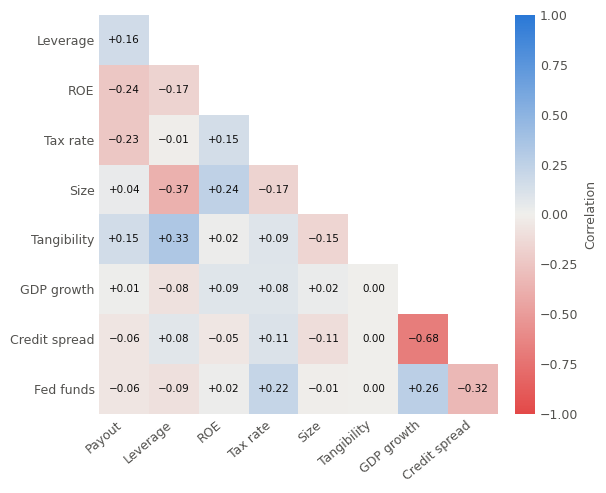

In [26]:
# Fig 1 — correlation matrix (lower triangle)
NAMES = {"payout": "Payout", "lev": "Leverage", "roe": "ROE", "tax": "Tax rate", "size": "Size",
         "tangibility": "Tangibility", "gdp_growth": "GDP growth", "cred_spread": "Credit spread", "ffr": "Fed funds"}
cv = [c for c in NAMES if c in panel and panel[c].notna().any()]
corr = panel[cv].corr().to_numpy()
M = np.where(np.tril(np.ones_like(corr), -1).astype(bool), corr, np.nan)[1:, :-1]
cmap = diverging(T)
fig, ax = plt.subplots(figsize=(6.5, 5.0))
im = ax.imshow(M, vmin=-1, vmax=1, cmap=cmap)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if not np.isnan(M[i, j]):
            ax.text(j, i, minus(M[i, j], "+.2f"), ha="center", va="center", fontsize=7.5,
                    color=ink_on(cmap((M[i, j] + 1) / 2), T))
ax.set_xticks(range(len(cv) - 1)); ax.set_xticklabels([NAMES[c] for c in cv[:-1]], rotation=40, ha="right")
ax.set_yticks(range(len(cv) - 1)); ax.set_yticklabels([NAMES[c] for c in cv[1:]])
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, fraction=0.04, pad=0.03); cb.outline.set_visible(False); cb.ax.tick_params(length=0)
cb.set_label("Correlation", color=T["ink2"])
fig.tight_layout(); save_fig(fig, OUTDIR / "fig_corr_heatmap.png", dpi=FIG_DPI, close=False, quantize=False); plt.show()

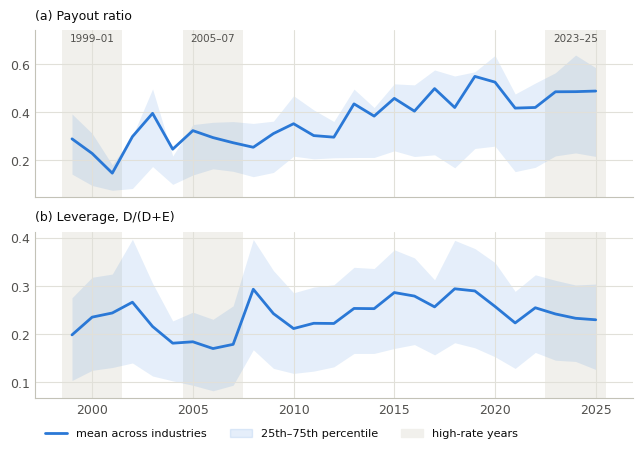

In [27]:
# Fig 2 — payout and leverage over time: mean and interquartile range, high-rate years shaded
years_ = sorted(panel["year"].unique())
episodes = runs(years_, [y in set(macro.loc[macro.high_rate == 1, "year"]) for y in years_])
fig, axes = plt.subplots(2, 1, figsize=(6.5, 4.6), sharex=True)
for ax, v, title in [(axes[0], "payout", "(a) Payout ratio"), (axes[1], "lev", "(b) Leverage, D/(D+E)")]:
    g = panel.groupby("year")[v]
    shade(ax, episodes, T, color=T["band"], alpha=1)
    ax.fill_between(years_, g.quantile(.25), g.quantile(.75), color=T["s1"], alpha=.12, lw=0)
    ax.plot(years_, g.mean(), color=T["s1"])
    ax.set_title(title)
ylo, yhi = axes[0].get_ylim(); axes[0].set_ylim(ylo, yhi + .12 * (yhi - ylo))   # headroom for the labels
for ep in episodes:
    axes[0].text((ep[0] + ep[-1]) / 2, .98, f"{ep[0]}–{str(ep[-1])[2:]}", transform=axes[0].get_xaxis_transform(),
                 ha="center", va="top", fontsize=7.5, color=T["ink2"])
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
axes[1].legend([Line2D([], [], color=T["s1"]), Patch(color=T["s1"], alpha=.12), Patch(color=T["band"])],
               ["mean across industries", "25th–75th percentile", "high-rate years"], loc="upper left", ncol=3,
               bbox_to_anchor=(0, -0.12))
fig.tight_layout(); save_fig(fig, OUTDIR / "fig_payout_leverage_ts.png", dpi=FIG_DPI, close=False); plt.show()

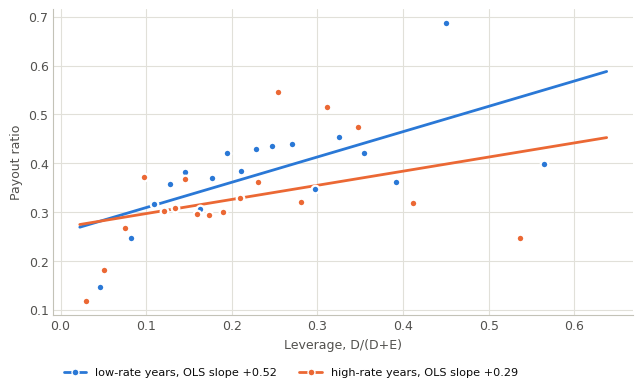

In [28]:
# Fig 3 — KEY H1/H2 visual: binned payout vs leverage by regime (descriptive, no fixed effects)
def binscatter(ax, d, x, y, color, nbins=18):
    d = d[[x, y]].dropna(); q = min(nbins, d[x].nunique())
    d = d.assign(_b=pd.qcut(d[x], q, duplicates="drop"))
    g = d.groupby("_b", observed=True).agg(xx=(x, "mean"), yy=(y, "mean"))
    b = np.polyfit(d[x], d[y], 1); xs = np.linspace(d[x].min(), d[x].max(), 50)
    ax.plot(xs, np.polyval(b, xs), color=color, lw=2, zorder=2)
    dot(ax, g["xx"], g["yy"], color, T, size=30)
    return b[0]
fig, ax = plt.subplots(figsize=(6.5, 4.0))
from matplotlib.lines import Line2D
handles, labels = [], []
for flag, color, lab in [(0, T["s1"], "low-rate years"), (1, T["s2"], "high-rate years")]:
    slope = binscatter(ax, panel[panel.high_rate == flag], "lev", "payout", color)
    handles.append(Line2D([], [], color=color, lw=2, marker="o", ms=5, mec=T["surface"]))
    labels.append(f"{lab}, OLS slope {minus(slope)}")
ax.set_xlabel("Leverage, D/(D+E)"); ax.set_ylabel("Payout ratio")
ax.legend(handles, labels, loc="upper left", ncol=2, bbox_to_anchor=(0, -0.14))
fig.tight_layout(); save_fig(fig, OUTDIR / "fig_payout_vs_leverage_by_regime.png", dpi=FIG_DPI, close=False)
plt.show()

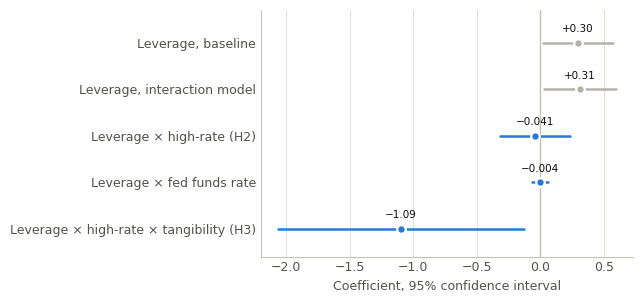

In [29]:
# Fig 4 — key coefficients (95% CI, industry-clustered); hypothesis terms in blue
def grab(res, key, label, hyp):
    if res is None or not hasattr(res, "params") or key not in res.params: return None
    b = res.params[key]; se = res.std_errors[key]; return (label, b, b - 1.96 * se, b + 1.96 * se, hyp)
specs = [grab(res_base, "lev", "Leverage, baseline", False), grab(res_int, "lev", "Leverage, interaction model", False),
         grab(res_int, "lev_x_high", "Leverage × high-rate (H2)", True),
         grab(res_cont, "lev_x_ffr", "Leverage × fed funds rate", True),
         grab(res_h3, "lev_x_high_x_tang", "Leverage × high-rate × tangibility (H3)", True)
         if "res_h3" in globals() else None]
specs = [s for s in specs if s]
fig, ax = plt.subplots(figsize=(6.5, 0.42 * len(specs) + 1.0))
ax.axvline(0, color=T["base"], lw=1)
for i, (lab, b, lo, hi, hyp) in enumerate(specs):
    c = T["s1"] if hyp else T["dim"]
    ax.plot([lo, hi], [i, i], color=c, lw=1.8)
    dot(ax, b, i, c, T, size=38)
    ax.text(b, i - 0.18, minus(b, "+.3f" if abs(b) < .1 else "+.2f"), ha="center", va="bottom", fontsize=7.5, color=T["ink"])
ax.set_yticks(range(len(specs))); ax.set_yticklabels([s[0] for s in specs]); ax.invert_yaxis()
ax.grid(axis="y", visible=False); ax.set_ylim(len(specs) - 0.4, -0.7)
ax.set_xlabel("Coefficient, 95% confidence interval")
fig.tight_layout(); save_fig(fig, OUTDIR / "fig_coefficient_forest.png", dpi=FIG_DPI, close=False); plt.show()

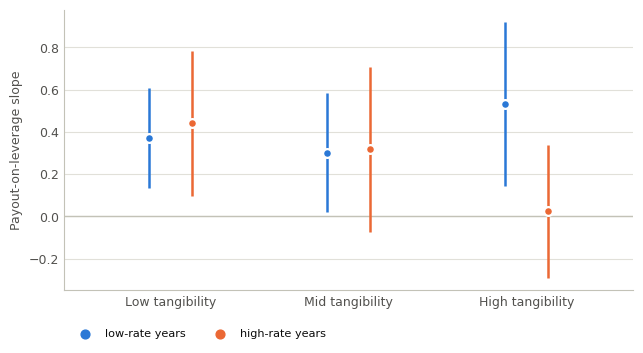

In [30]:
# Fig 5 — H3: payout-on-leverage slope by tangibility tercile and regime (descriptive)
import statsmodels.formula.api as smf
if panel["tangibility"].notna().any():
    panel["tang_grp"] = pd.qcut(panel["tangibility"], 3, labels=["low", "mid", "high"], duplicates="drop")
    cells = []
    for g in ["low", "mid", "high"]:
        for hr, lab in [(0, "low-rate"), (1, "high-rate")]:
            sub = panel[(panel.tang_grp == g) & (panel.high_rate == hr)][["payout", "lev"]].dropna()
            if len(sub) > 10:
                m = smf.ols("payout ~ lev", sub).fit(cov_type="HC1")
                cells.append((g, lab, m.params["lev"], m.bse["lev"]))
    cdf = pd.DataFrame(cells, columns=["tang", "regime", "slope", "se"])
    groups = ["low", "mid", "high"]; x = np.arange(len(groups))
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    ax.axhline(0, color=T["base"], lw=1)
    for k, (reg, col) in enumerate([("low-rate", T["s1"]), ("high-rate", T["s2"])]):
        s = cdf[cdf.regime == reg].set_index("tang").reindex(groups)
        xs = x + (k - .5) * 0.24
        ax.vlines(xs, s["slope"] - 1.96 * s["se"], s["slope"] + 1.96 * s["se"], color=col, lw=1.8)
        dot(ax, xs, s["slope"], col, T, size=40)
    ax.set_xticks(x); ax.set_xticklabels([f"{g.capitalize()} tangibility" for g in groups])
    ax.grid(axis="x", visible=False); ax.set_xlim(-0.6, len(groups) - 0.4)
    ax.set_ylabel("Payout-on-leverage slope")
    h1 = ax.scatter([], [], s=40, color=T["s1"]); h2 = ax.scatter([], [], s=40, color=T["s2"])
    ax.legend([h1, h2], ["low-rate years", "high-rate years"], loc="upper left", ncol=2, bbox_to_anchor=(0, -0.1))
    fig.tight_layout(); save_fig(fig, OUTDIR / "fig_H3_slopes_by_tangibility.png", dpi=FIG_DPI, close=False)
    plt.show()

## 12 · Reproducibility & outputs  <span style="color:gray">(Appendices B & D)</span>

In [31]:
# Appendix B — industry persistence table
appendix_B = (persist.rename("years_present").reset_index()
              .assign(in_core=lambda d: d["industry"].isin(CORE)))
appendix_B.to_csv(OUTDIR / "appendix_B_industry_persistence.csv", index=False)
pd.Series(INDUSTRY_RENAME, name="canonical").rename_axis("original").to_csv(OUTDIR / "appendix_B_rename_map.csv")

panel.to_csv(OUTDIR / "analysis_panel.csv", index=False)
try: panel.to_parquet(OUTDIR / "analysis_panel.parquet", index=False)
except Exception: pass

print(f"Saved {len(list(OUTDIR.glob('*')))} files to {OUTDIR}/\n")
print(f"Panel: {panel['industry'].nunique()} industries x {panel['year'].nunique()} years "
      f"({panel.year.min()}-{panel.year.max()}) = {len(panel)} obs; core = {len(CORE)} industries\n")
for m in ["pandas", "numpy", "matplotlib", "statsmodels", "linearmodels", "xlrd"]:
    try: print(f"  {m:13s}", __import__(m).__version__)
    except Exception: print(f"  {m:13s} (missing)")
print("  python       ", sys.version.split()[0])

Saved 31 files to outputs/

Panel: 143 industries x 27 years (1999-2025) = 2116 obs; core = 46 industries

  pandas        3.0.2
  numpy         2.4.4
  matplotlib    3.10.9
  statsmodels   0.15.0
  linearmodels  7.0
  xlrd          2.0.2
  python        3.11.15


---
### Summary

- **Full 1999–2025 industry panel** built reproducibly from the Damodaran archives (era-proof loader) plus
  FRED macro data. Sample: US non-financial, non-utility industries.
- **Hypotheses tested directly:** H1/H2 via the `lev × HighRate` interaction (primary regime = rate-level
  threshold; post-2022 binary as robustness); H3 via the `lev × HighRate × tangibility` triple interaction.
- **Industry reconciliation** (Appendix B) handles Damodaran's 2012→2013 reclassification conservatively;
  a **stable-core sample** provides a robustness check immune to it.
- **Tangibility (H3)** is PP&E / total assets (within-year rank); the capex-based proxies are robustness checks.
- **Alternative leverage (§9d):** market leverage without leases, book leverage and Debt/EBITDA (debt relative
  to cash flow, also interacted with the fed funds rate as an interest-burden proxy).
- **H3 fragility (§10b):** the negative triple term survives dropping any single industry, but not dropping
  the 2023–2025 episode, and it is not significant at 5% after adjusting for multiple testing: exploratory.
- **Data-quality fixes:** depreciation-based tangibility excluded in 2013–2015 (capex depreciation break);
  rows whose firm count does not match `divfund` (a shifted block in `wacc99`) set to missing;
  ratios with a non-positive denominator (payout when ROE ≤ 0, Dividends/FCFE when FCFE ≤ 0) set to missing;
  H3 includes the tangibility main effect; macro controls enter only the industry-FE-only specification.
- **Robustness (§9)** also drops the financial crisis (2008–09) and adds a growth / reinvestment control
  (capital spending intensity); neither changes the H2 null.
- **Power and bounds (§9b):** the H2 null is reported as a bound: the confidence interval rules out
  regime effects above a few payout points per SD of leverage, while smaller effects cannot be excluded.
- **Dividend smoothing (§8b):** dividends adjust slowly toward a target payout (Lintner), smoothing does not
  change across rate regimes, and H1 tested in change form (dividend changes) is not supported either.
- **Tests** (`tests/`, no downloads): on fake Damodaran files with planted effects and planted data defects,
  this notebook recovers the effects and catches the defects; the package functions have unit tests.
- **Outputs** (`outputs/`): combined regression table (CSV + LaTeX), hypothesis verdicts, descriptive and
  proxy-robustness tables, the variable and industry appendices, and six publication-ready figures.
- **Caveats to read in the thesis:** PP&E / assets changes definition in 2013 and 2017 (hence the ranks);
  the main leverage measure includes leases from 2013 on;
  industry-level aggregation; the data is a repeated cross-section; results are associational.